In [1]:
!pip install imblearn

In [1]:
# =============================
# IMPORTS
# =============================
import os
import time
import psutil

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import BorderlineSMOTE

In [2]:
# =============================
# DEVICE
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [3]:
# =============================
# DATA PATH
# =============================
DATA_PATH = "/kaggle/input/datasets/saxenadivyansh/all-three/all_three.csv"

In [4]:
# =============================
# CLEANING
# =============================
def clean_dataframe(df):
    df = df.dropna(subset=["label"])
    df["label"] = df["label"].astype(int)
    df = df[df["label"] >= 0]
    return df

df = clean_dataframe(pd.read_csv(DATA_PATH))


In [5]:
# =============================
# DATASET
# =============================
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [6]:
# =============================
# SIMPLE GNN LAYER
# =============================
class SimpleGNNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x):
        # Fully connected graph
        num_features = x.shape[1]
        A = torch.ones((num_features, num_features), device=x.device) / num_features
        x = torch.matmul(x, A)
        return torch.relu(self.linear(x))


In [7]:
# =============================
# MODEL: CNN + LSTM + GNN
# =============================
class RobustParallelModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        # CNN
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.cnn_fc = nn.Linear(32, hidden_dim)

        # LSTM
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.lstm_fc = nn.Linear(hidden_dim, hidden_dim)

        # GNN
        self.gnn1 = SimpleGNNLayer(input_dim, hidden_dim)
        self.gnn2 = SimpleGNNLayer(hidden_dim, hidden_dim)

        # Fusion weights
        self.fusion_weights = nn.Parameter(torch.ones(3))

        # Classifier
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # CNN
        cnn_out = self.pool(self.conv1(x.unsqueeze(1))).squeeze(-1)
        cnn_feat = torch.relu(self.cnn_fc(cnn_out))

        # LSTM
        lstm_out, _ = self.lstm(x.unsqueeze(1))
        lstm_feat = torch.relu(self.lstm_fc(lstm_out[:, -1, :]))

        # GNN
        gnn_feat = self.gnn1(x)
        gnn_feat = self.gnn2(gnn_feat)

        # Softmax fusion
        weights = torch.softmax(self.fusion_weights, dim=0)
        fused = (
            weights[0] * cnn_feat +
            weights[1] * lstm_feat +
            weights[2] * gnn_feat
        )

        output = self.classifier(fused)
        return torch.log_softmax(output, dim=1)



In [8]:
# =============================
# TRAIN FUNCTION
# =============================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)

        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total



In [9]:
# =============================
# EVALUATION
# =============================
def evaluate(model, loader):
    model.eval()
    preds, true, probs = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            prob = torch.exp(outputs)

            preds.extend(torch.argmax(prob, dim=1).cpu().numpy())
            true.extend(y.cpu().numpy())
            probs.extend(prob.cpu().numpy())

    preds, true, probs = map(np.array, (preds, true, probs))
    acc = accuracy_score(true, preds)

    num_classes = probs.shape[1]
    true_bin = label_binarize(true, classes=np.arange(num_classes))

    try:
        roc = roc_auc_score(true_bin, probs, multi_class='ovr', average='weighted')
    except:
        roc = np.nan

    return acc, roc, preds, true, probs


# Borderline SMOTE

In [19]:
def run_split(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    # =============================
    # DATA PREP
    # =============================
    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # =============================
    # BEFORE SAMPLING
    # =============================
    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train BEFORE Sampling"
    )
    plt.show()

    # =============================
    # SMOTE
    # =============================
    smote = BorderlineSMOTE()
    X_train, y_train = smote.fit_resample(X_train, y_train)

    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train AFTER Sampling"
    )
    plt.show()

    # =============================
    # SCALING
    # =============================
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    pd.Series(y_test).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Test Distribution"
    )
    plt.show()

    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    # =============================
    # LOADERS
    # =============================
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # =============================
    # MODEL (UPDATED)
    # =============================
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # =============================
    # TRAINING
    # =============================
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # =============================
    # LOSS + ACCURACY PLOT
    # =============================
    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(history["loss"], color="red", label="Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], color="blue", label="Train Acc")
    ax2.plot(history["val_acc"], color="green", label="Val Acc")
    ax2.set_ylabel("Accuracy")

    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # =============================
    # CONFUSION MATRIX
    # =============================
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # =============================
    # ROC CURVE
    # =============================
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc_val:.2f})")

    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # =============================
    # PRECISION-RECALL CURVE
    # =============================
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # =============================
    # RUNTIME + MEMORY
    # =============================
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\n⏱️ Runtime: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========


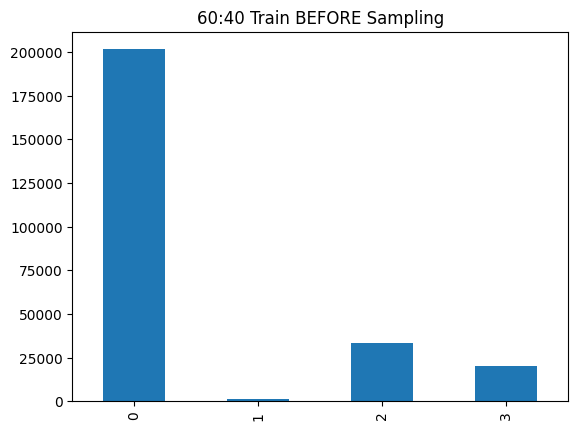

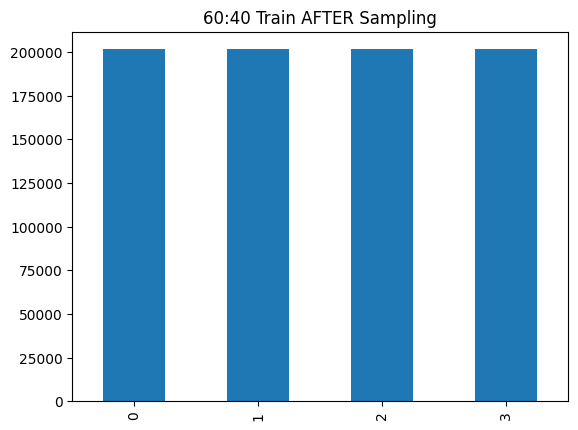

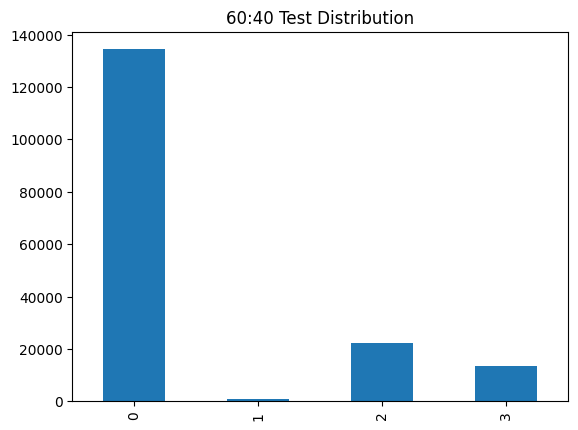

Train size: 806032
Test size : 171050
Epoch 1: Loss=0.0615, TrainAcc=0.9799, TestAcc=0.9735, ROC-AUC=0.9986
Epoch 2: Loss=0.0304, TrainAcc=0.9905, TestAcc=0.9795, ROC-AUC=0.9992
Epoch 3: Loss=0.0264, TrainAcc=0.9917, TestAcc=0.9765, ROC-AUC=0.9992
Epoch 4: Loss=0.0246, TrainAcc=0.9921, TestAcc=0.9777, ROC-AUC=0.9993
Epoch 5: Loss=0.0233, TrainAcc=0.9925, TestAcc=0.9804, ROC-AUC=0.9993
Epoch 6: Loss=0.0226, TrainAcc=0.9929, TestAcc=0.9810, ROC-AUC=0.9993
Epoch 7: Loss=0.0219, TrainAcc=0.9931, TestAcc=0.9817, ROC-AUC=0.9993
Epoch 8: Loss=0.0212, TrainAcc=0.9934, TestAcc=0.9823, ROC-AUC=0.9994
Epoch 9: Loss=0.0209, TrainAcc=0.9934, TestAcc=0.9826, ROC-AUC=0.9992
Epoch 10: Loss=0.0201, TrainAcc=0.9937, TestAcc=0.9827, ROC-AUC=0.9994
Epoch 11: Loss=0.0199, TrainAcc=0.9937, TestAcc=0.9829, ROC-AUC=0.9994
Epoch 12: Loss=0.0195, TrainAcc=0.9938, TestAcc=0.9825, ROC-AUC=0.9994
Epoch 13: Loss=0.0193, TrainAcc=0.9939, TestAcc=0.9837, ROC-AUC=0.9993
Epoch 14: Loss=0.0191, TrainAcc=0.9941, TestAcc=

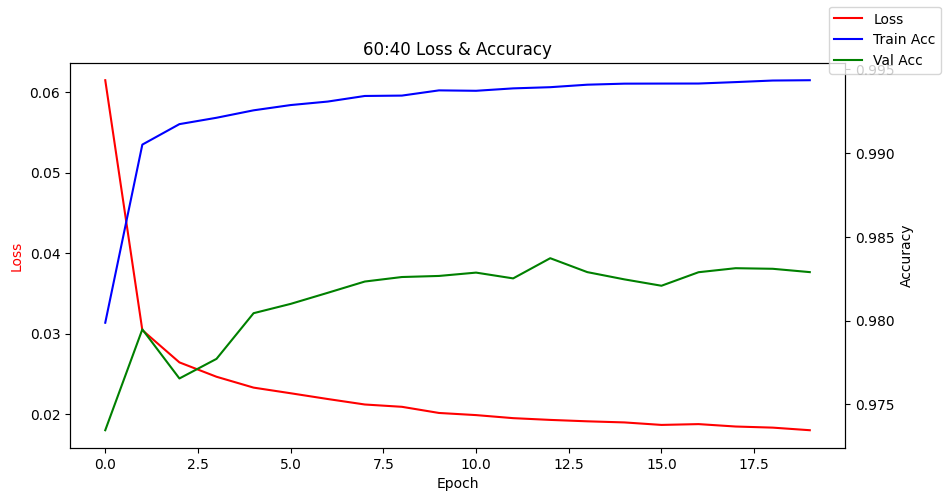

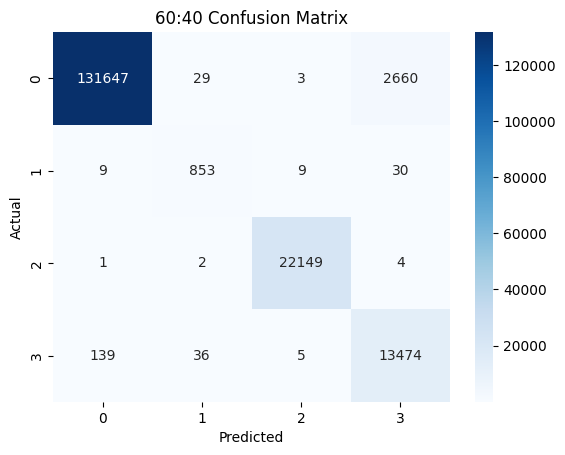

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.93      0.95      0.94       901
           2       1.00      1.00      1.00     22156
           3       0.83      0.99      0.90     13654

    accuracy                           0.98    171050
   macro avg       0.94      0.98      0.96    171050
weighted avg       0.99      0.98      0.98    171050



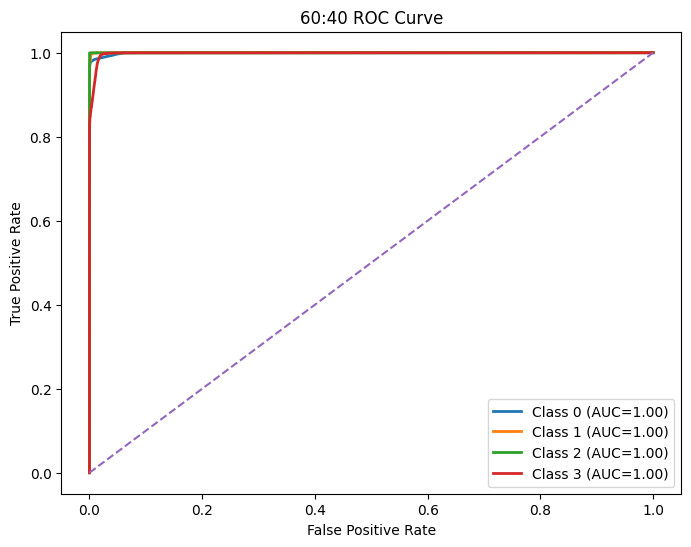

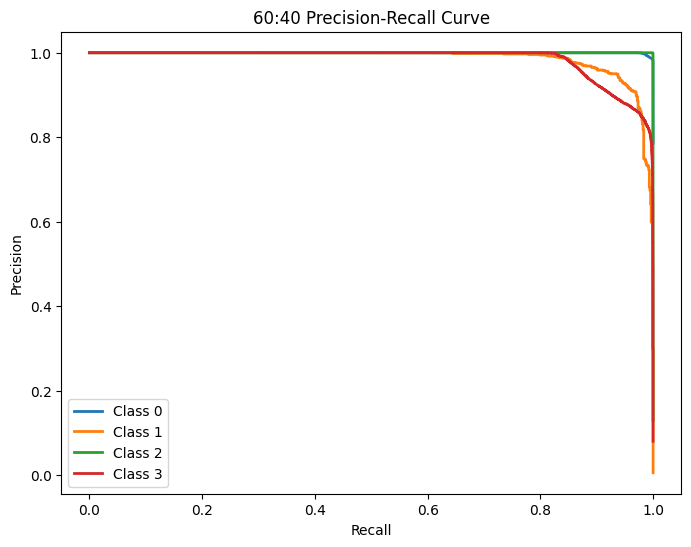


⏱️ Runtime: 1151.88 sec
💾 RAM used: 1096.00 MB

========== 70:30 ==========


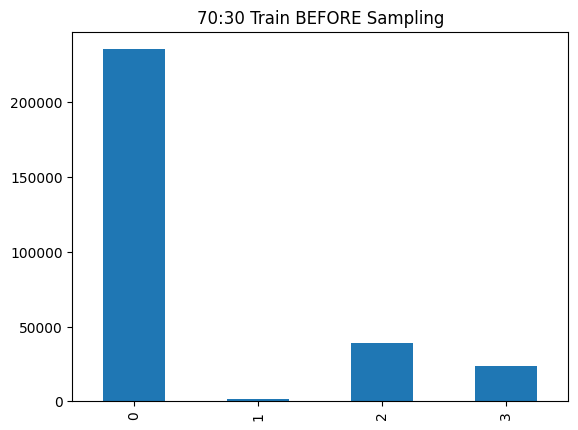

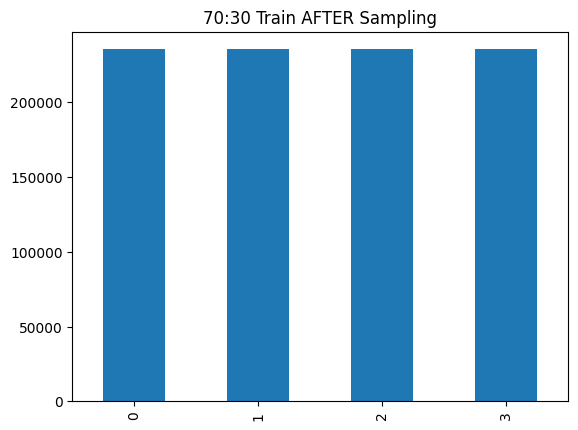

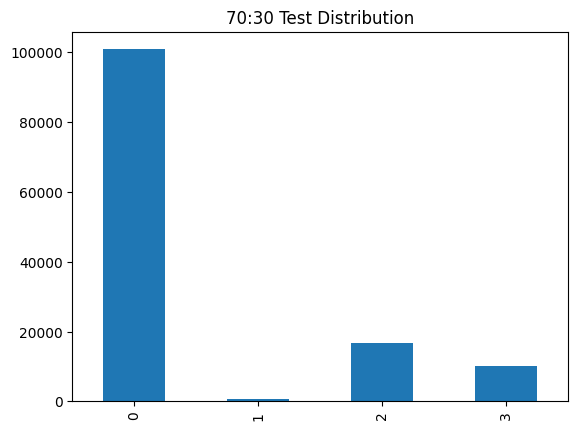

Train size: 940368
Test size : 128288
Epoch 1: Loss=0.0591, TrainAcc=0.9807, TestAcc=0.9736, ROC-AUC=0.9988
Epoch 2: Loss=0.0294, TrainAcc=0.9908, TestAcc=0.9785, ROC-AUC=0.9991
Epoch 3: Loss=0.0261, TrainAcc=0.9918, TestAcc=0.9801, ROC-AUC=0.9992
Epoch 4: Loss=0.0247, TrainAcc=0.9923, TestAcc=0.9808, ROC-AUC=0.9992
Epoch 5: Loss=0.0235, TrainAcc=0.9927, TestAcc=0.9812, ROC-AUC=0.9994
Epoch 6: Loss=0.0223, TrainAcc=0.9931, TestAcc=0.9814, ROC-AUC=0.9994
Epoch 7: Loss=0.0216, TrainAcc=0.9933, TestAcc=0.9825, ROC-AUC=0.9993
Epoch 8: Loss=0.0210, TrainAcc=0.9935, TestAcc=0.9815, ROC-AUC=0.9994
Epoch 9: Loss=0.0207, TrainAcc=0.9936, TestAcc=0.9817, ROC-AUC=0.9994
Epoch 10: Loss=0.0203, TrainAcc=0.9937, TestAcc=0.9819, ROC-AUC=0.9994
Epoch 11: Loss=0.0198, TrainAcc=0.9939, TestAcc=0.9832, ROC-AUC=0.9994
Epoch 12: Loss=0.0196, TrainAcc=0.9939, TestAcc=0.9831, ROC-AUC=0.9994
Epoch 13: Loss=0.0194, TrainAcc=0.9940, TestAcc=0.9830, ROC-AUC=0.9994
Epoch 14: Loss=0.0192, TrainAcc=0.9941, TestAcc=

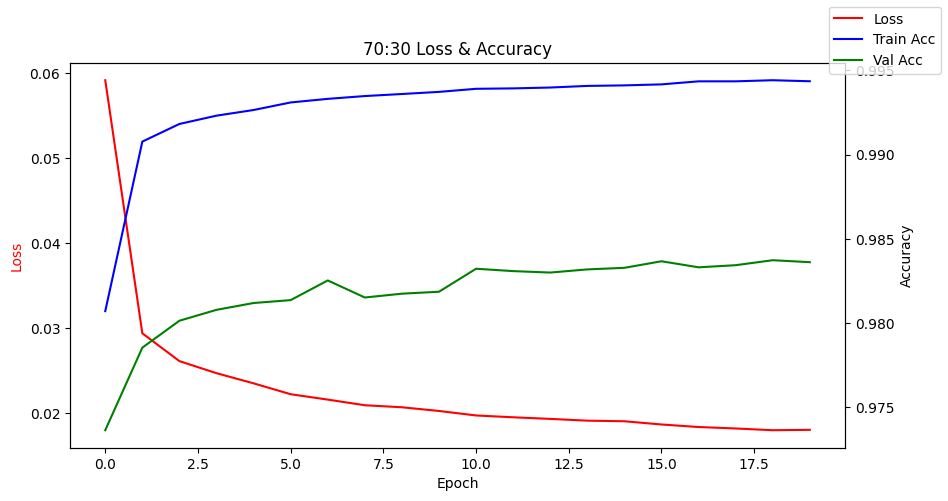

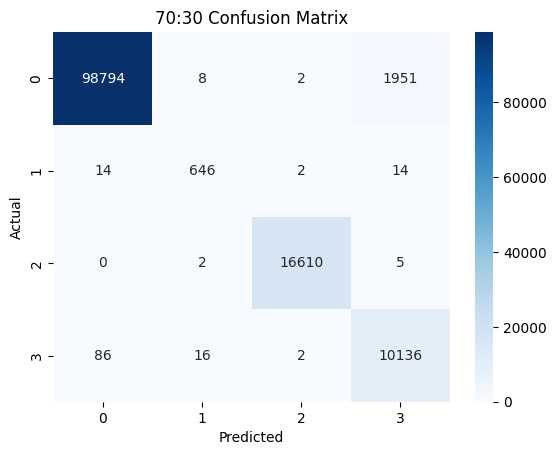

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.96      0.96      0.96       676
           2       1.00      1.00      1.00     16617
           3       0.84      0.99      0.91     10240

    accuracy                           0.98    128288
   macro avg       0.95      0.98      0.96    128288
weighted avg       0.99      0.98      0.98    128288



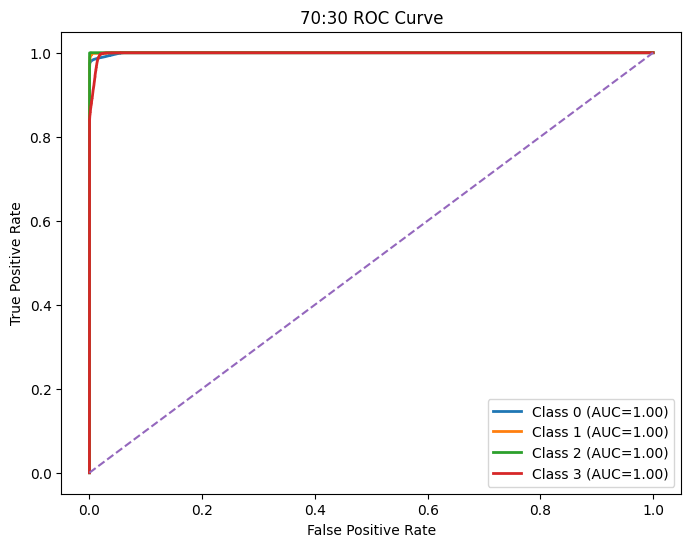

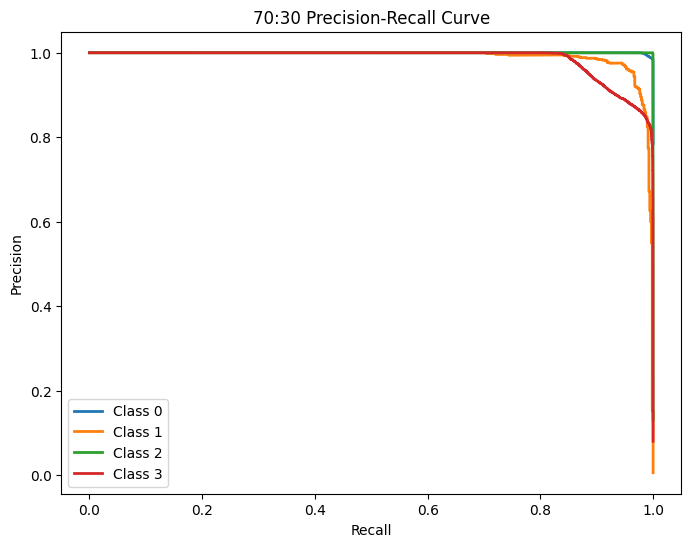


⏱️ Runtime: 1305.33 sec
💾 RAM used: 380.85 MB

========== 80:20 ==========


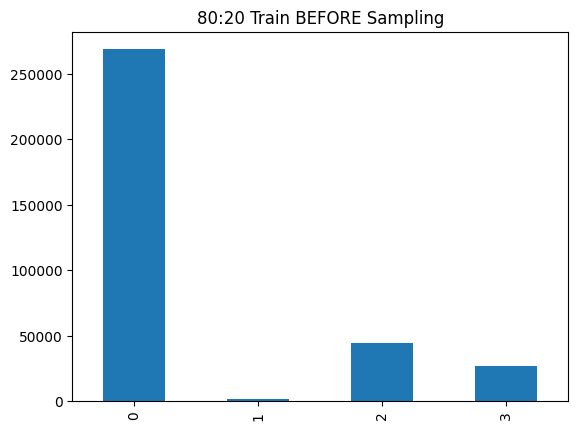

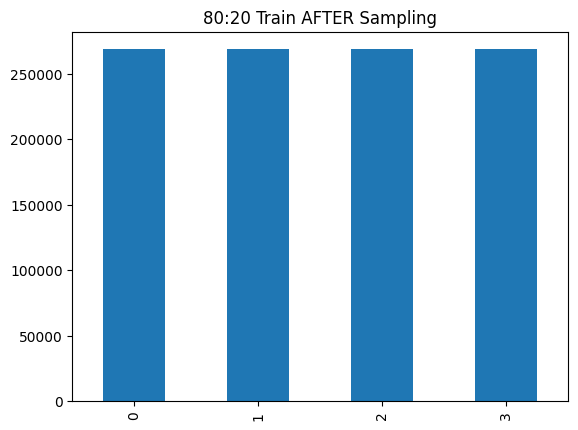

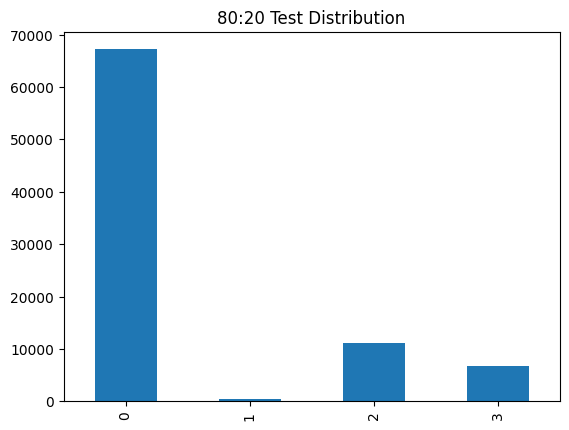

Train size: 1074712
Test size : 85525
Epoch 1: Loss=0.0553, TrainAcc=0.9819, TestAcc=0.9769, ROC-AUC=0.9990
Epoch 2: Loss=0.0299, TrainAcc=0.9905, TestAcc=0.9798, ROC-AUC=0.9992
Epoch 3: Loss=0.0262, TrainAcc=0.9918, TestAcc=0.9790, ROC-AUC=0.9992
Epoch 4: Loss=0.0243, TrainAcc=0.9925, TestAcc=0.9821, ROC-AUC=0.9992
Epoch 5: Loss=0.0229, TrainAcc=0.9929, TestAcc=0.9819, ROC-AUC=0.9993
Epoch 6: Loss=0.0224, TrainAcc=0.9932, TestAcc=0.9802, ROC-AUC=0.9993
Epoch 7: Loss=0.0216, TrainAcc=0.9934, TestAcc=0.9822, ROC-AUC=0.9994
Epoch 8: Loss=0.0211, TrainAcc=0.9935, TestAcc=0.9812, ROC-AUC=0.9994
Epoch 9: Loss=0.0204, TrainAcc=0.9937, TestAcc=0.9828, ROC-AUC=0.9993
Epoch 10: Loss=0.0203, TrainAcc=0.9937, TestAcc=0.9818, ROC-AUC=0.9994
Epoch 11: Loss=0.0200, TrainAcc=0.9938, TestAcc=0.9811, ROC-AUC=0.9993
Epoch 12: Loss=0.0198, TrainAcc=0.9940, TestAcc=0.9830, ROC-AUC=0.9994
Epoch 13: Loss=0.0196, TrainAcc=0.9940, TestAcc=0.9834, ROC-AUC=0.9994
Epoch 14: Loss=0.0194, TrainAcc=0.9940, TestAcc=

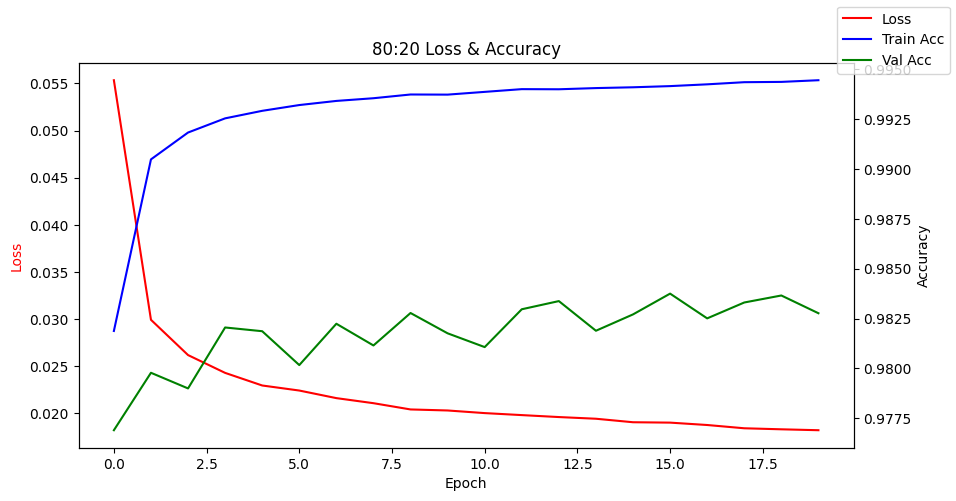

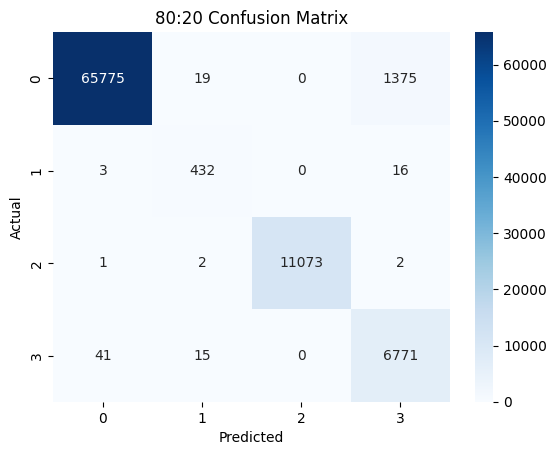

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.92      0.96      0.94       451
           2       1.00      1.00      1.00     11078
           3       0.83      0.99      0.90      6827

    accuracy                           0.98     85525
   macro avg       0.94      0.98      0.96     85525
weighted avg       0.99      0.98      0.98     85525



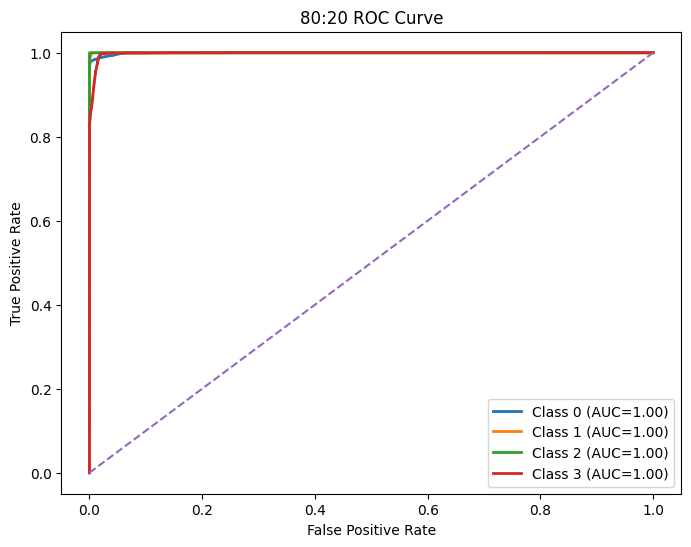

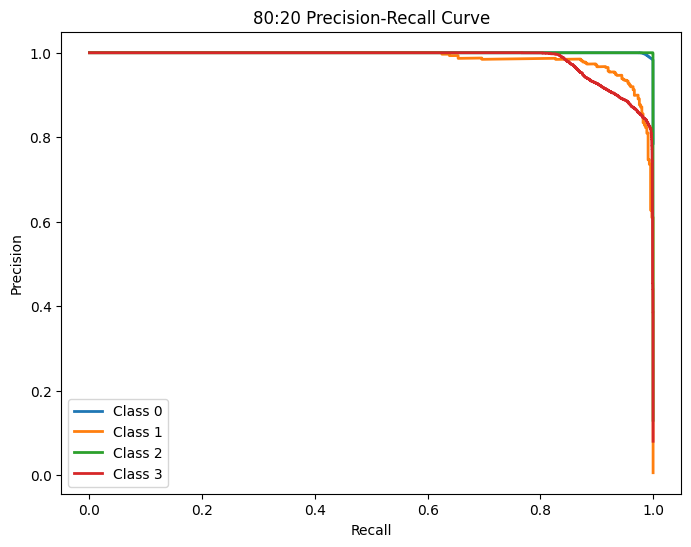


⏱️ Runtime: 1464.47 sec
💾 RAM used: 442.54 MB


In [20]:
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split(df, "60:40", test_size=0.4)
run_split(df, "70:30", test_size=0.3)
run_split(df, "80:20", test_size=0.2)

# SMOTE

In [21]:
from imblearn.over_sampling import SMOTE

def run_split_smote(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    # =============================
    # DATA PREP
    # =============================
    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # =============================
    # BEFORE SAMPLING
    # =============================
    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train BEFORE Sampling"
    )
    plt.show()

    # =============================
    # SMOTE (STANDARD)
    # =============================
    smote = SMOTE(random_state=42)   # ✅ CHANGED HERE
    X_train, y_train = smote.fit_resample(X_train, y_train)

    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train AFTER SMOTE"
    )
    plt.show()

    # =============================
    # SCALING
    # =============================
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    pd.Series(y_test).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Test Distribution"
    )
    plt.show()

    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    # =============================
    # LOADERS
    # =============================
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # =============================
    # MODEL
    # =============================
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # =============================
    # TRAINING
    # =============================
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # =============================
    # LOSS + ACCURACY PLOT
    # =============================
    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(history["loss"], color="red", label="Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], color="blue", label="Train Acc")
    ax2.plot(history["val_acc"], color="green", label="Val Acc")
    ax2.set_ylabel("Accuracy")

    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # =============================
    # CONFUSION MATRIX
    # =============================
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # =============================
    # ROC CURVE
    # =============================
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc_val:.2f})")

    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # =============================
    # PRECISION-RECALL CURVE
    # =============================
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # =============================
    # RUNTIME + MEMORY
    # =============================
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\n⏱️ Runtime: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========


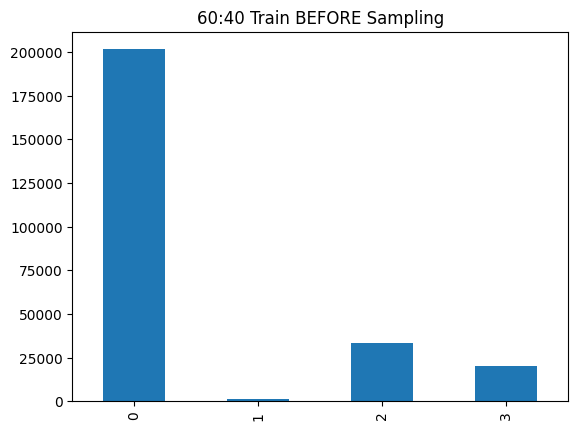

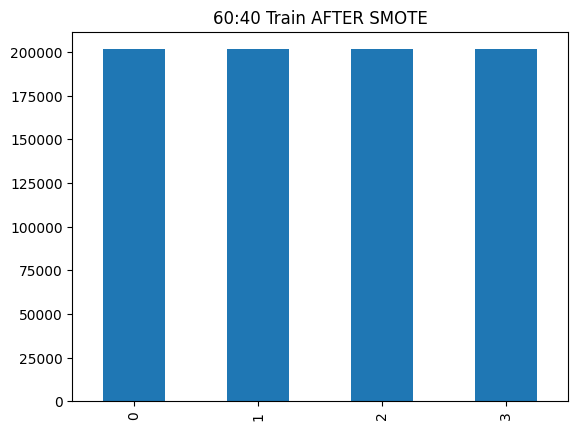

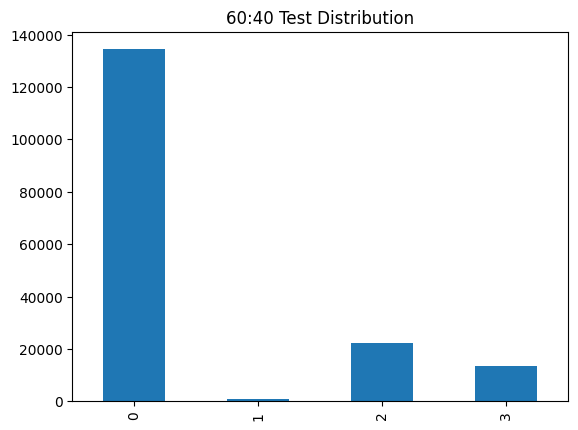

Train size: 806032
Test size : 171050
Epoch 1: Loss=0.0615, TrainAcc=0.9795, TestAcc=0.9776, ROC-AUC=0.9990
Epoch 2: Loss=0.0291, TrainAcc=0.9901, TestAcc=0.9747, ROC-AUC=0.9990
Epoch 3: Loss=0.0248, TrainAcc=0.9916, TestAcc=0.9808, ROC-AUC=0.9992
Epoch 4: Loss=0.0231, TrainAcc=0.9921, TestAcc=0.9759, ROC-AUC=0.9992
Epoch 5: Loss=0.0215, TrainAcc=0.9926, TestAcc=0.9808, ROC-AUC=0.9993
Epoch 6: Loss=0.0208, TrainAcc=0.9928, TestAcc=0.9823, ROC-AUC=0.9994
Epoch 7: Loss=0.0200, TrainAcc=0.9932, TestAcc=0.9816, ROC-AUC=0.9993
Epoch 8: Loss=0.0195, TrainAcc=0.9932, TestAcc=0.9822, ROC-AUC=0.9994
Epoch 9: Loss=0.0188, TrainAcc=0.9934, TestAcc=0.9831, ROC-AUC=0.9994
Epoch 10: Loss=0.0187, TrainAcc=0.9935, TestAcc=0.9790, ROC-AUC=0.9993
Epoch 11: Loss=0.0186, TrainAcc=0.9935, TestAcc=0.9828, ROC-AUC=0.9994
Epoch 12: Loss=0.0183, TrainAcc=0.9936, TestAcc=0.9831, ROC-AUC=0.9994
Epoch 13: Loss=0.0180, TrainAcc=0.9938, TestAcc=0.9807, ROC-AUC=0.9993
Epoch 14: Loss=0.0180, TrainAcc=0.9937, TestAcc=

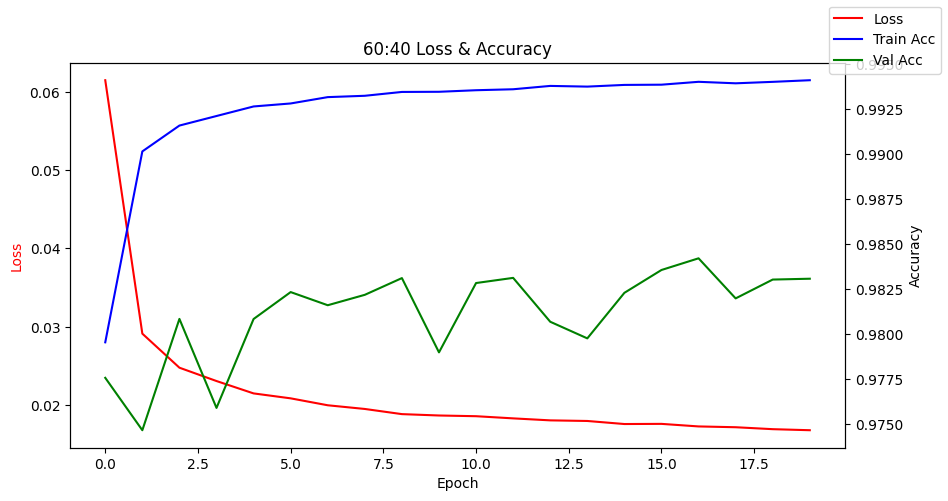

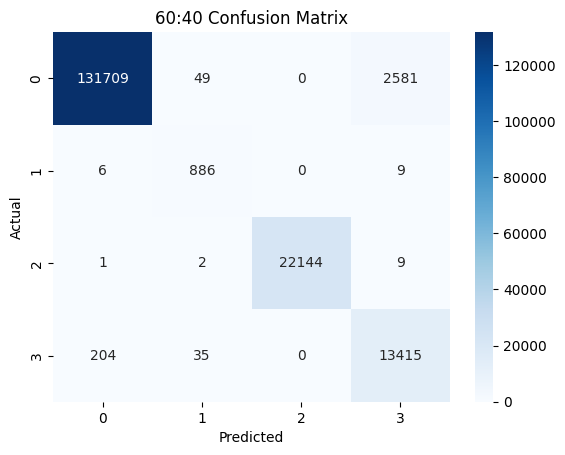

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.91      0.98      0.95       901
           2       1.00      1.00      1.00     22156
           3       0.84      0.98      0.90     13654

    accuracy                           0.98    171050
   macro avg       0.94      0.99      0.96    171050
weighted avg       0.99      0.98      0.98    171050



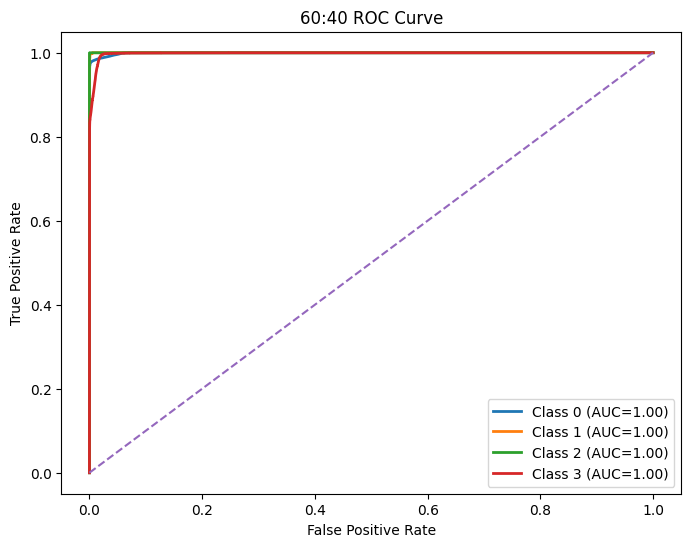

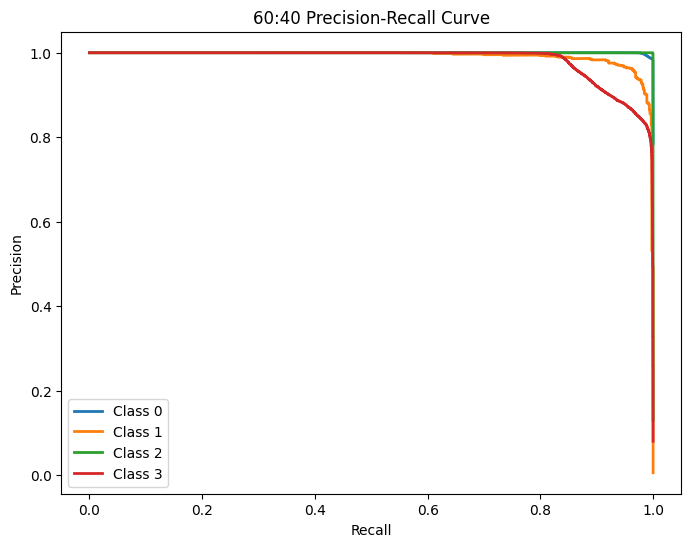


⏱️ Runtime: 1099.84 sec
💾 RAM used: 323.65 MB

========== 70:30 ==========


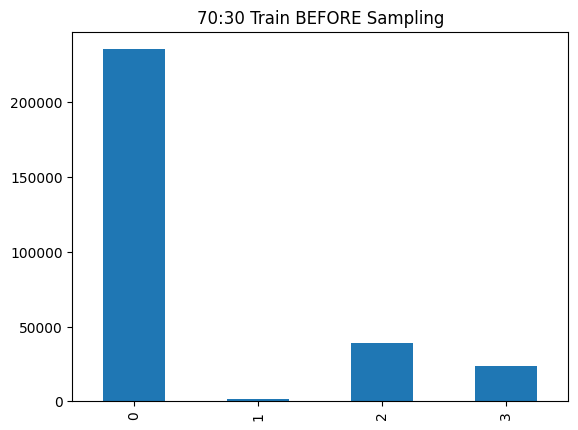

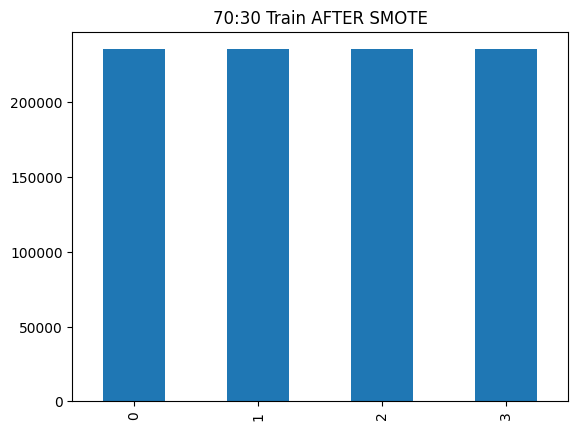

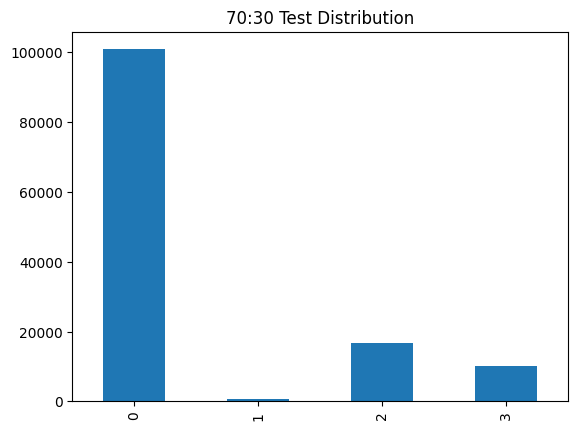

Train size: 940368
Test size : 128288
Epoch 1: Loss=0.0608, TrainAcc=0.9802, TestAcc=0.9758, ROC-AUC=0.9990
Epoch 2: Loss=0.0277, TrainAcc=0.9906, TestAcc=0.9755, ROC-AUC=0.9991
Epoch 3: Loss=0.0242, TrainAcc=0.9917, TestAcc=0.9789, ROC-AUC=0.9993
Epoch 4: Loss=0.0219, TrainAcc=0.9925, TestAcc=0.9805, ROC-AUC=0.9993
Epoch 5: Loss=0.0207, TrainAcc=0.9928, TestAcc=0.9806, ROC-AUC=0.9993
Epoch 6: Loss=0.0200, TrainAcc=0.9930, TestAcc=0.9814, ROC-AUC=0.9993
Epoch 7: Loss=0.0194, TrainAcc=0.9932, TestAcc=0.9803, ROC-AUC=0.9993
Epoch 8: Loss=0.0192, TrainAcc=0.9934, TestAcc=0.9825, ROC-AUC=0.9993
Epoch 9: Loss=0.0188, TrainAcc=0.9934, TestAcc=0.9827, ROC-AUC=0.9993
Epoch 10: Loss=0.0181, TrainAcc=0.9936, TestAcc=0.9826, ROC-AUC=0.9994
Epoch 11: Loss=0.0181, TrainAcc=0.9936, TestAcc=0.9817, ROC-AUC=0.9993
Epoch 12: Loss=0.0177, TrainAcc=0.9938, TestAcc=0.9815, ROC-AUC=0.9993
Epoch 13: Loss=0.0177, TrainAcc=0.9938, TestAcc=0.9837, ROC-AUC=0.9994
Epoch 14: Loss=0.0178, TrainAcc=0.9938, TestAcc=

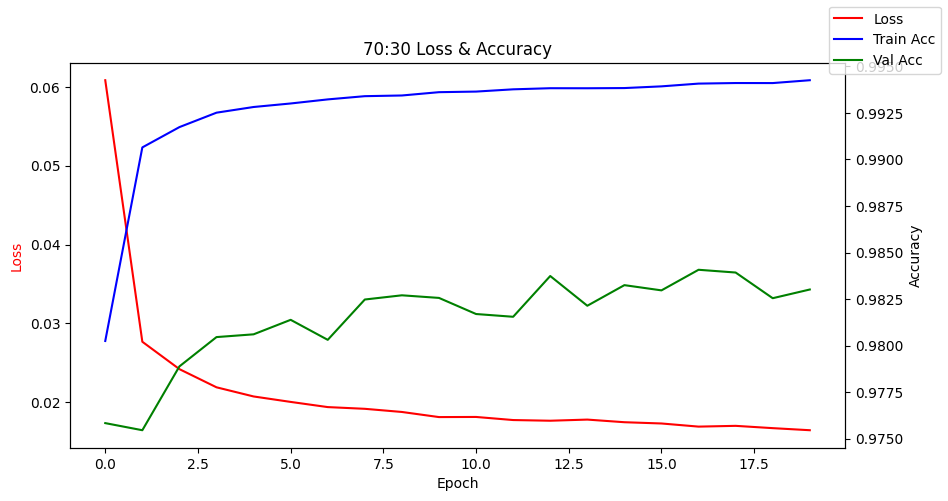

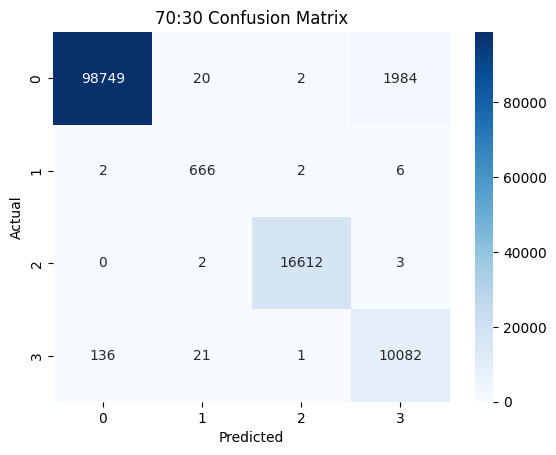

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.94      0.99      0.96       676
           2       1.00      1.00      1.00     16617
           3       0.83      0.98      0.90     10240

    accuracy                           0.98    128288
   macro avg       0.94      0.99      0.96    128288
weighted avg       0.99      0.98      0.98    128288



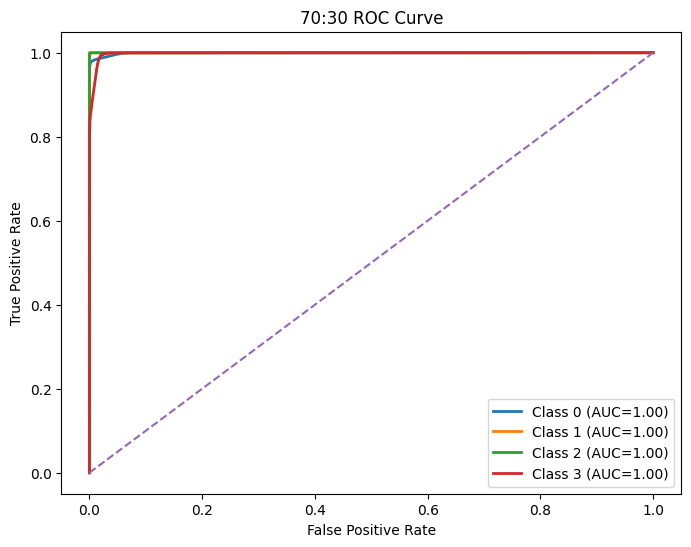

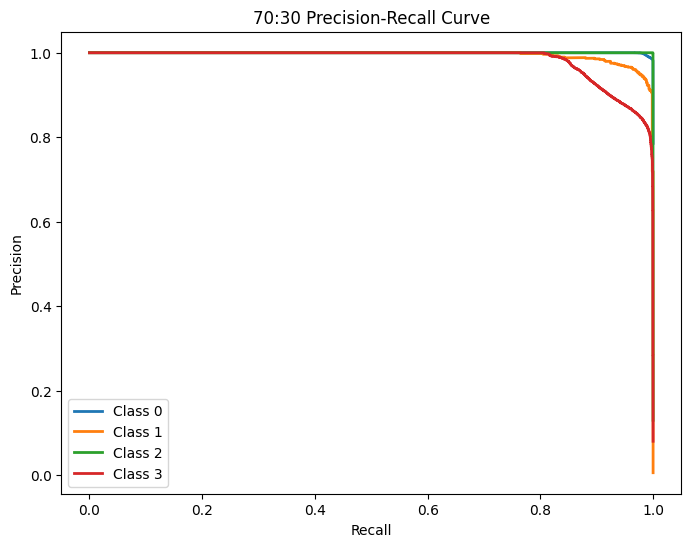


⏱️ Runtime: 1261.90 sec
💾 RAM used: 336.58 MB

========== 80:20 ==========


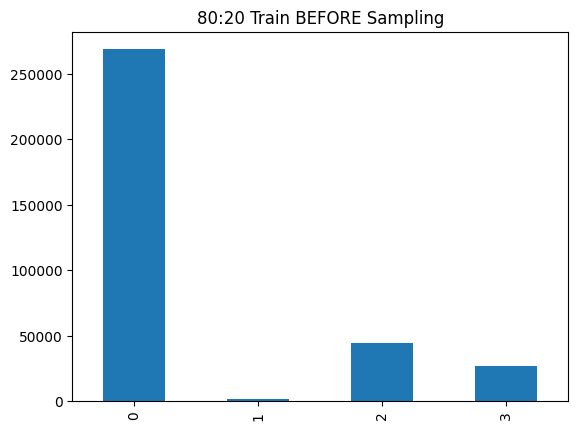

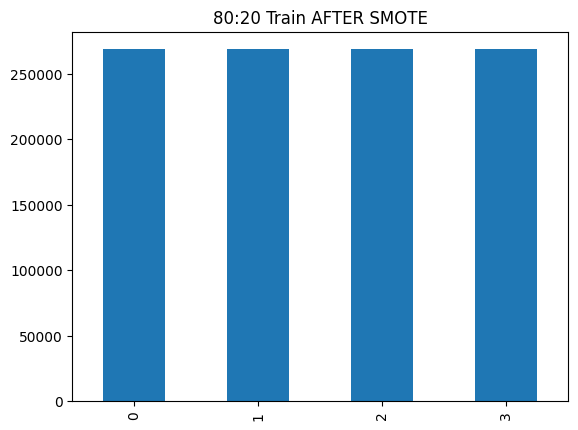

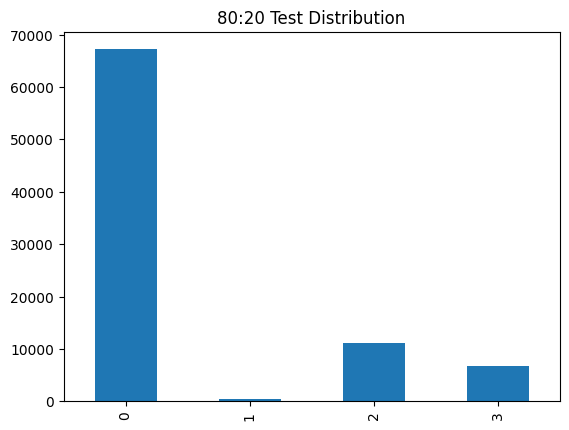

Train size: 1074712
Test size : 85525
Epoch 1: Loss=0.0544, TrainAcc=0.9815, TestAcc=0.9714, ROC-AUC=0.9990
Epoch 2: Loss=0.0270, TrainAcc=0.9907, TestAcc=0.9791, ROC-AUC=0.9992
Epoch 3: Loss=0.0235, TrainAcc=0.9919, TestAcc=0.9785, ROC-AUC=0.9992
Epoch 4: Loss=0.0219, TrainAcc=0.9924, TestAcc=0.9790, ROC-AUC=0.9992
Epoch 5: Loss=0.0209, TrainAcc=0.9927, TestAcc=0.9829, ROC-AUC=0.9993
Epoch 6: Loss=0.0199, TrainAcc=0.9931, TestAcc=0.9818, ROC-AUC=0.9993
Epoch 7: Loss=0.0192, TrainAcc=0.9933, TestAcc=0.9823, ROC-AUC=0.9994
Epoch 8: Loss=0.0189, TrainAcc=0.9934, TestAcc=0.9825, ROC-AUC=0.9993
Epoch 9: Loss=0.0187, TrainAcc=0.9935, TestAcc=0.9818, ROC-AUC=0.9993
Epoch 10: Loss=0.0183, TrainAcc=0.9936, TestAcc=0.9834, ROC-AUC=0.9994
Epoch 11: Loss=0.0177, TrainAcc=0.9938, TestAcc=0.9824, ROC-AUC=0.9994
Epoch 12: Loss=0.0174, TrainAcc=0.9939, TestAcc=0.9819, ROC-AUC=0.9994
Epoch 13: Loss=0.0176, TrainAcc=0.9938, TestAcc=0.9815, ROC-AUC=0.9993
Epoch 14: Loss=0.0176, TrainAcc=0.9939, TestAcc=

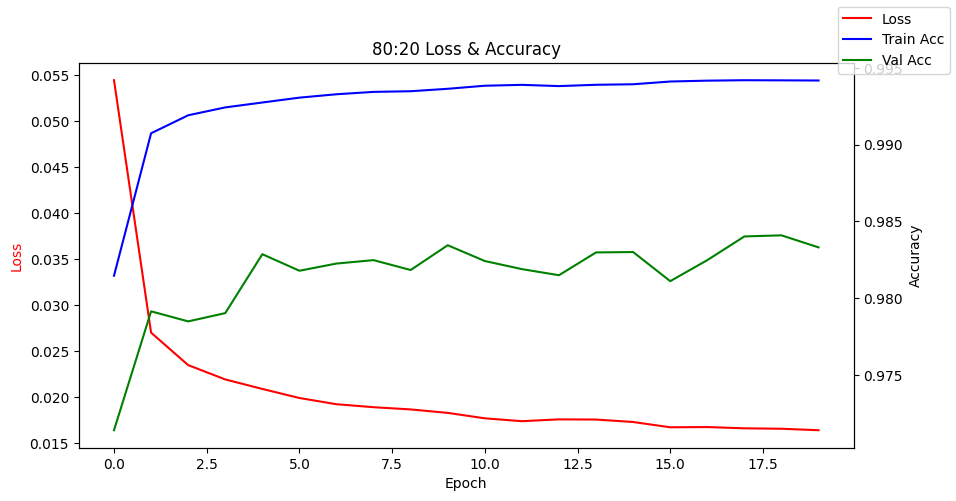

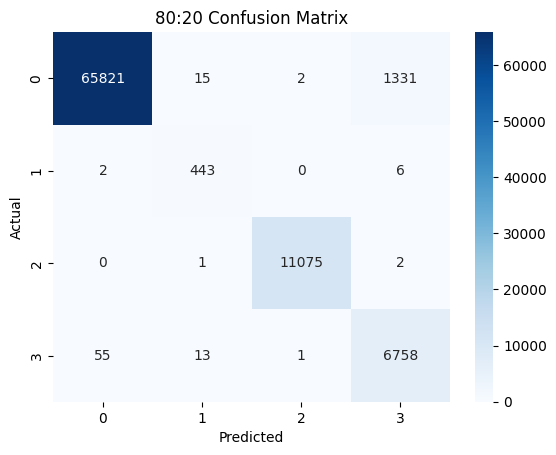

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.94      0.98      0.96       451
           2       1.00      1.00      1.00     11078
           3       0.83      0.99      0.91      6827

    accuracy                           0.98     85525
   macro avg       0.94      0.99      0.96     85525
weighted avg       0.99      0.98      0.98     85525



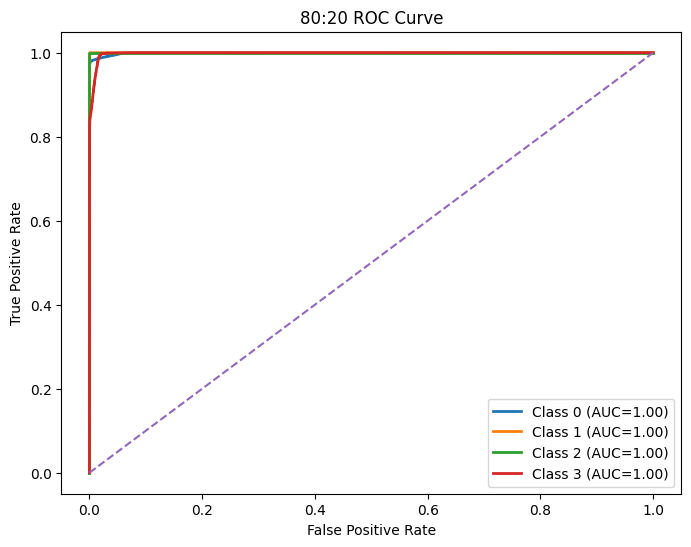

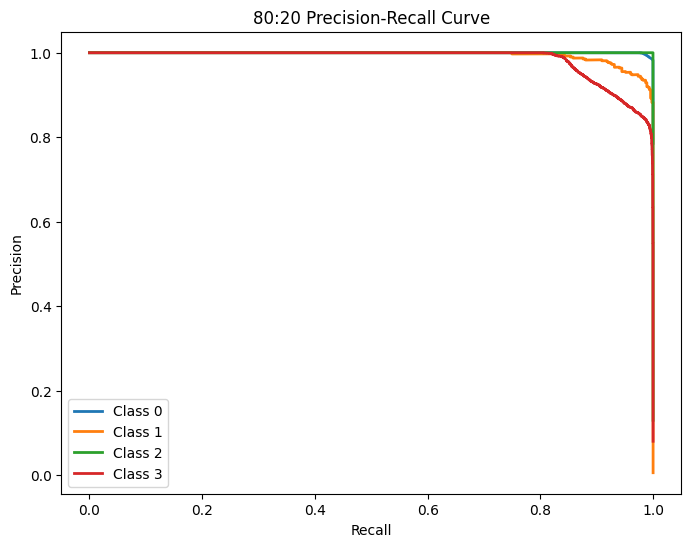


⏱️ Runtime: 1414.74 sec
💾 RAM used: 377.50 MB


In [22]:
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_smote(df, "60:40", test_size=0.4)
run_split_smote(df, "70:30", test_size=0.3)
run_split_smote(df, "80:20", test_size=0.2)

# ADASYN

In [23]:
from imblearn.over_sampling import ADASYN   # ✅ CHANGED HERE



def run_split_adasyn(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    # =============================
    # DATA PREP
    # =============================
    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # =============================
    # BEFORE SAMPLING
    # =============================
    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train BEFORE Sampling"
    )
    plt.show()

    # =============================
    # ADASYN (Adaptive Sampling)
    # =============================
    adasyn = ADASYN(random_state=42)   # ✅ CHANGED HERE
    X_train, y_train = adasyn.fit_resample(X_train, y_train)

    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train AFTER ADASYN"
    )
    plt.show()

    # =============================
    # SCALING
    # =============================
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    pd.Series(y_test).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Test Distribution"
    )
    plt.show()

    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    # =============================
    # LOADERS
    # =============================
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # =============================
    # MODEL
    # =============================
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # =============================
    # TRAINING
    # =============================
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # =============================
    # LOSS + ACCURACY PLOT
    # =============================
    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(history["loss"], color="red", label="Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], color="blue", label="Train Acc")
    ax2.plot(history["val_acc"], color="green", label="Val Acc")
    ax2.set_ylabel("Accuracy")

    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # =============================
    # CONFUSION MATRIX
    # =============================
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # =============================
    # ROC CURVE
    # =============================
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc_val:.2f})")

    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # =============================
    # PRECISION-RECALL CURVE
    # =============================
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # =============================
    # RUNTIME + MEMORY
    # =============================
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\n⏱️ Runtime: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========


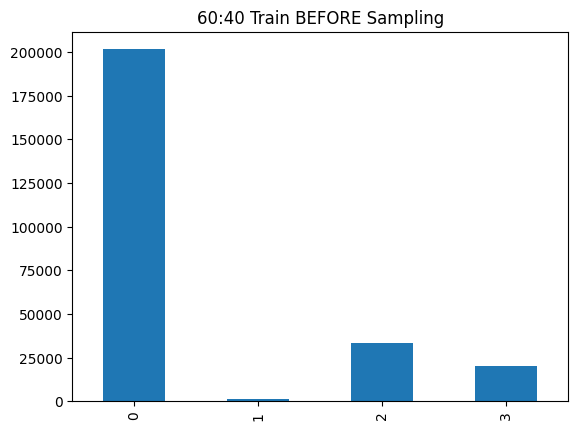

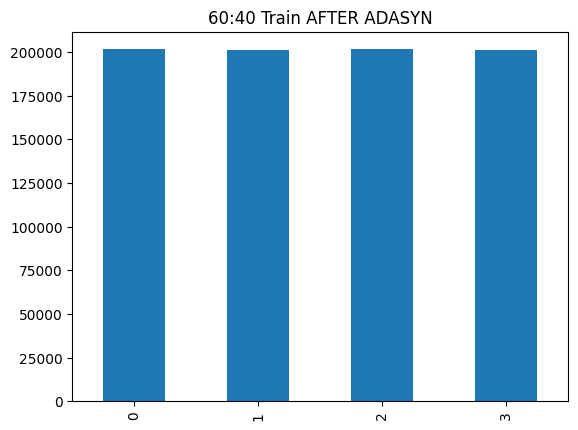

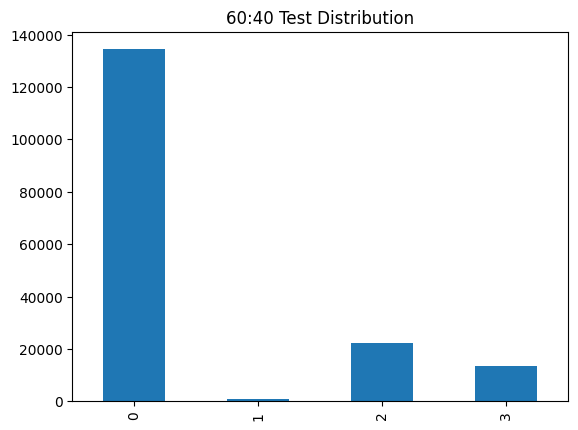

Train size: 805442
Test size : 171050
Epoch 1: Loss=0.0795, TrainAcc=0.9757, TestAcc=0.9756, ROC-AUC=0.9988
Epoch 2: Loss=0.0369, TrainAcc=0.9886, TestAcc=0.9710, ROC-AUC=0.9989
Epoch 3: Loss=0.0320, TrainAcc=0.9902, TestAcc=0.9783, ROC-AUC=0.9991
Epoch 4: Loss=0.0291, TrainAcc=0.9909, TestAcc=0.9796, ROC-AUC=0.9991
Epoch 5: Loss=0.0276, TrainAcc=0.9914, TestAcc=0.9795, ROC-AUC=0.9992
Epoch 6: Loss=0.0251, TrainAcc=0.9920, TestAcc=0.9778, ROC-AUC=0.9992
Epoch 7: Loss=0.0248, TrainAcc=0.9921, TestAcc=0.9798, ROC-AUC=0.9993
Epoch 8: Loss=0.0240, TrainAcc=0.9925, TestAcc=0.9822, ROC-AUC=0.9993
Epoch 9: Loss=0.0230, TrainAcc=0.9927, TestAcc=0.9786, ROC-AUC=0.9993
Epoch 10: Loss=0.0225, TrainAcc=0.9929, TestAcc=0.9812, ROC-AUC=0.9993
Epoch 11: Loss=0.0221, TrainAcc=0.9930, TestAcc=0.9793, ROC-AUC=0.9993
Epoch 12: Loss=0.0212, TrainAcc=0.9933, TestAcc=0.9820, ROC-AUC=0.9993
Epoch 13: Loss=0.0205, TrainAcc=0.9935, TestAcc=0.9825, ROC-AUC=0.9994
Epoch 14: Loss=0.0204, TrainAcc=0.9936, TestAcc=

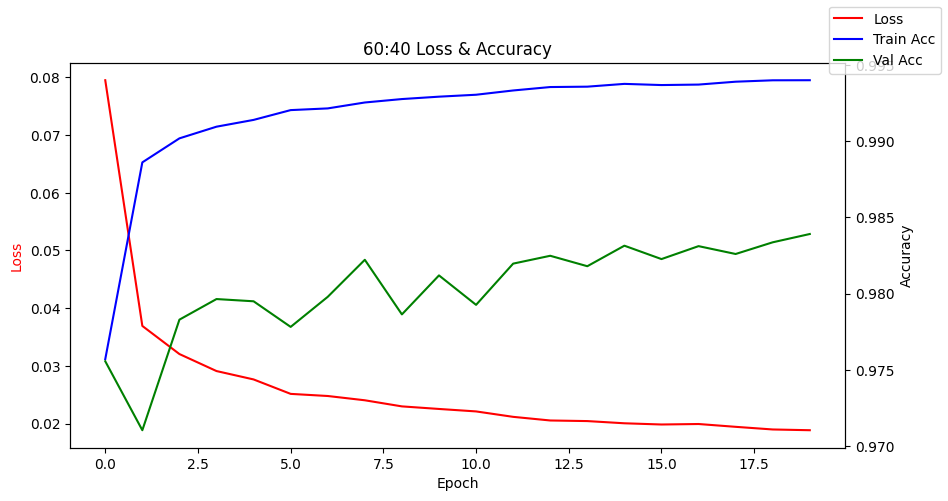

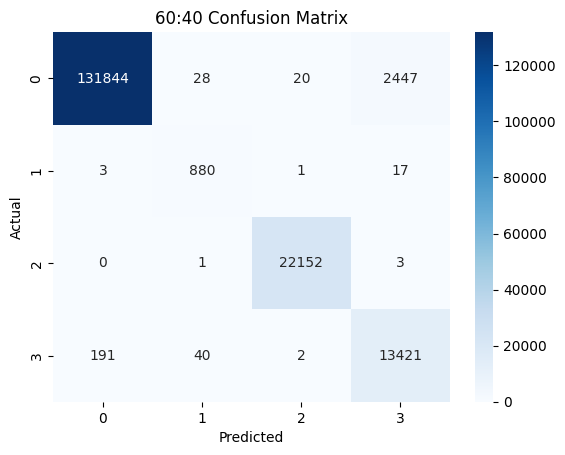

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.93      0.98      0.95       901
           2       1.00      1.00      1.00     22156
           3       0.84      0.98      0.91     13654

    accuracy                           0.98    171050
   macro avg       0.94      0.99      0.96    171050
weighted avg       0.99      0.98      0.98    171050



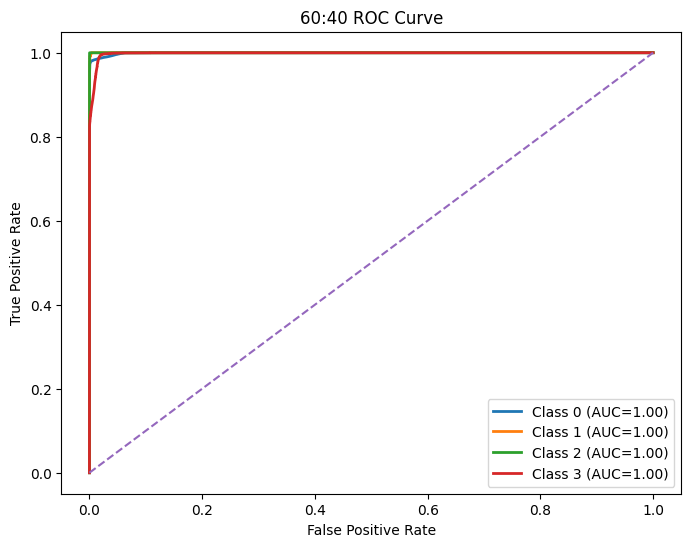

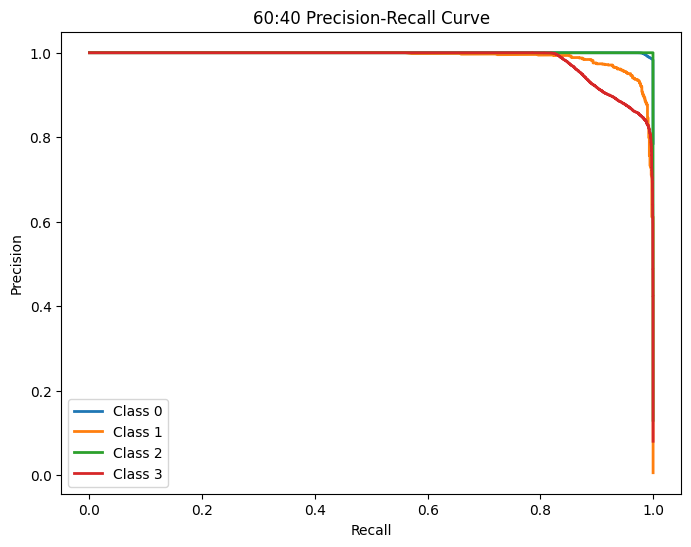


⏱️ Runtime: 1143.66 sec
💾 RAM used: 326.61 MB

========== 70:30 ==========


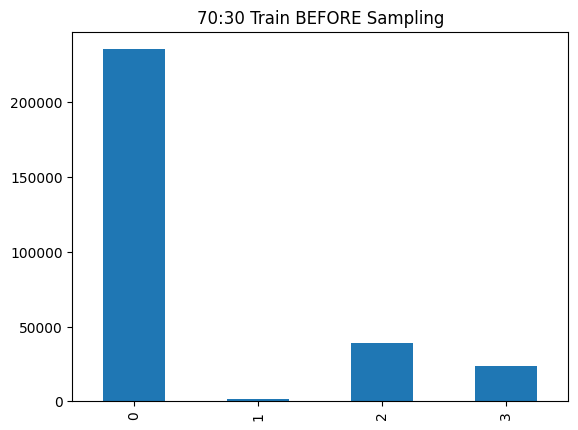

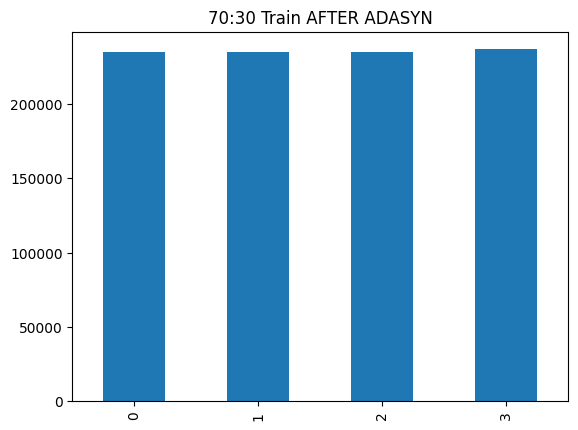

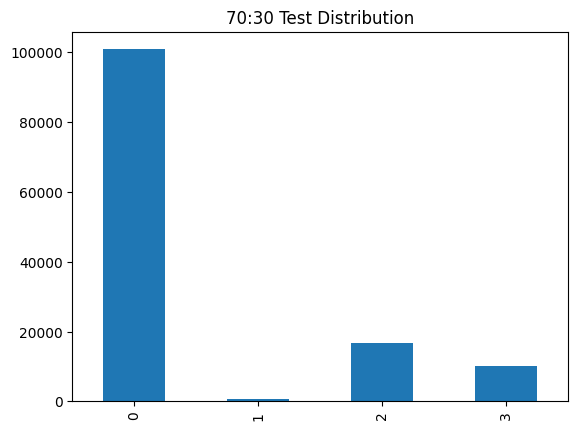

Train size: 942085
Test size : 128288
Epoch 1: Loss=0.0773, TrainAcc=0.9762, TestAcc=0.9780, ROC-AUC=0.9987
Epoch 2: Loss=0.0353, TrainAcc=0.9892, TestAcc=0.9774, ROC-AUC=0.9993
Epoch 3: Loss=0.0300, TrainAcc=0.9906, TestAcc=0.9800, ROC-AUC=0.9992
Epoch 4: Loss=0.0271, TrainAcc=0.9915, TestAcc=0.9803, ROC-AUC=0.9992
Epoch 5: Loss=0.0258, TrainAcc=0.9920, TestAcc=0.9809, ROC-AUC=0.9993
Epoch 6: Loss=0.0245, TrainAcc=0.9923, TestAcc=0.9829, ROC-AUC=0.9993
Epoch 7: Loss=0.0234, TrainAcc=0.9927, TestAcc=0.9826, ROC-AUC=0.9993
Epoch 8: Loss=0.0229, TrainAcc=0.9930, TestAcc=0.9813, ROC-AUC=0.9993
Epoch 9: Loss=0.0227, TrainAcc=0.9931, TestAcc=0.9819, ROC-AUC=0.9994
Epoch 10: Loss=0.0223, TrainAcc=0.9931, TestAcc=0.9811, ROC-AUC=0.9993
Epoch 11: Loss=0.0216, TrainAcc=0.9933, TestAcc=0.9830, ROC-AUC=0.9994
Epoch 12: Loss=0.0212, TrainAcc=0.9935, TestAcc=0.9823, ROC-AUC=0.9994
Epoch 13: Loss=0.0209, TrainAcc=0.9935, TestAcc=0.9826, ROC-AUC=0.9993
Epoch 14: Loss=0.0203, TrainAcc=0.9937, TestAcc=

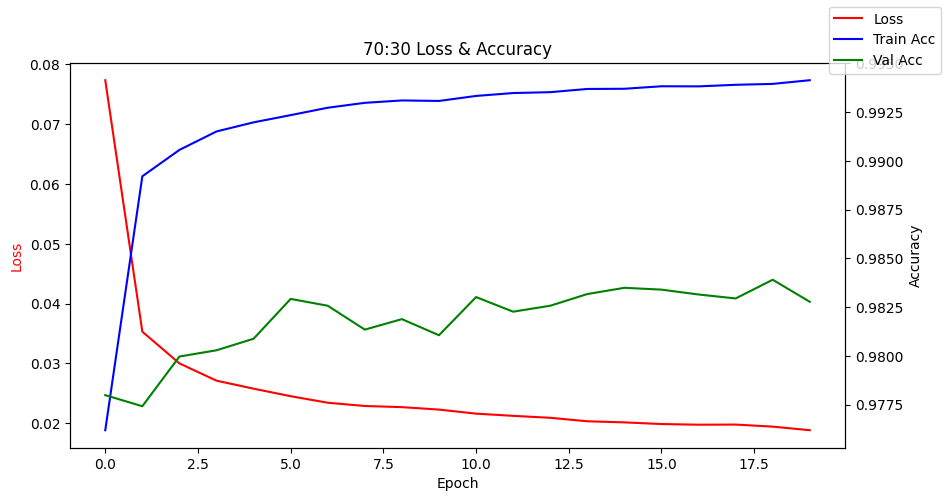

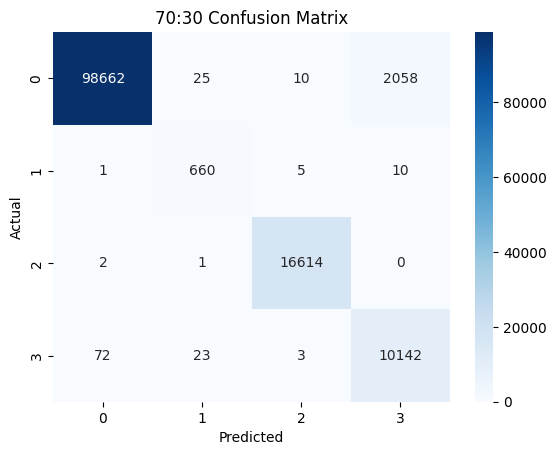

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.93      0.98      0.95       676
           2       1.00      1.00      1.00     16617
           3       0.83      0.99      0.90     10240

    accuracy                           0.98    128288
   macro avg       0.94      0.99      0.96    128288
weighted avg       0.99      0.98      0.98    128288



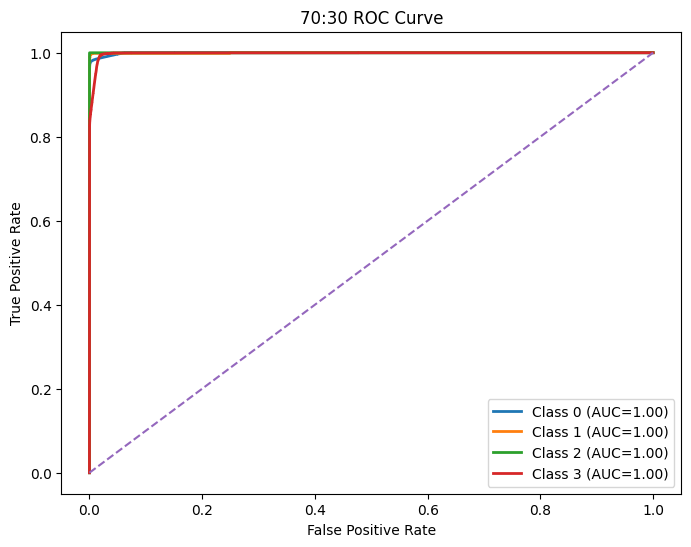

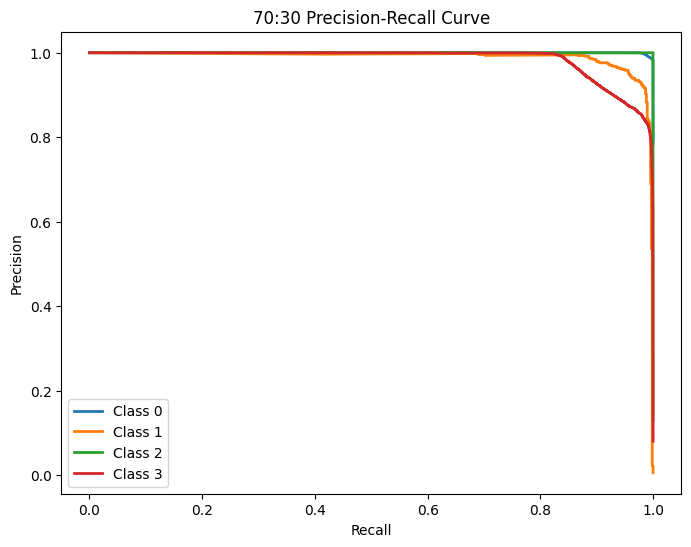


⏱️ Runtime: 1300.35 sec
💾 RAM used: 368.15 MB

========== 80:20 ==========


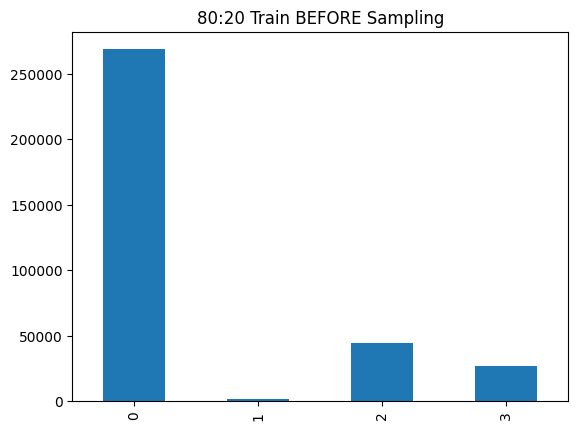

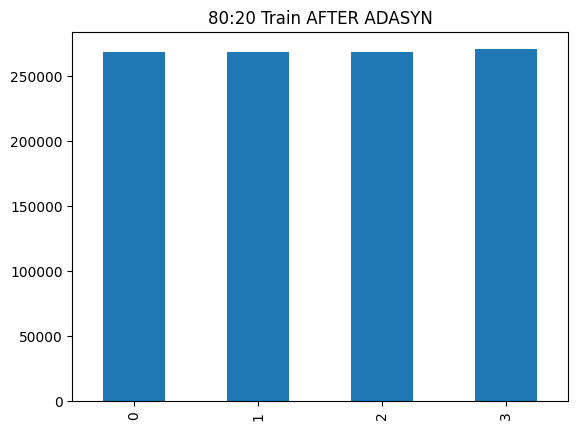

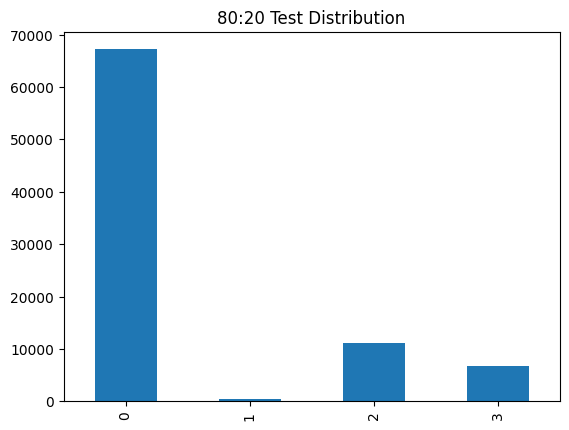

Train size: 1076489
Test size : 85525
Epoch 1: Loss=0.0753, TrainAcc=0.9777, TestAcc=0.9709, ROC-AUC=0.9988
Epoch 2: Loss=0.0353, TrainAcc=0.9892, TestAcc=0.9751, ROC-AUC=0.9991
Epoch 3: Loss=0.0301, TrainAcc=0.9906, TestAcc=0.9782, ROC-AUC=0.9992
Epoch 4: Loss=0.0272, TrainAcc=0.9917, TestAcc=0.9798, ROC-AUC=0.9992
Epoch 5: Loss=0.0262, TrainAcc=0.9920, TestAcc=0.9814, ROC-AUC=0.9993
Epoch 6: Loss=0.0248, TrainAcc=0.9923, TestAcc=0.9825, ROC-AUC=0.9994
Epoch 7: Loss=0.0237, TrainAcc=0.9926, TestAcc=0.9812, ROC-AUC=0.9994
Epoch 8: Loss=0.0236, TrainAcc=0.9927, TestAcc=0.9820, ROC-AUC=0.9994
Epoch 9: Loss=0.0227, TrainAcc=0.9929, TestAcc=0.9803, ROC-AUC=0.9993
Epoch 10: Loss=0.0217, TrainAcc=0.9933, TestAcc=0.9753, ROC-AUC=0.9993
Epoch 11: Loss=0.0218, TrainAcc=0.9933, TestAcc=0.9825, ROC-AUC=0.9994
Epoch 12: Loss=0.0216, TrainAcc=0.9934, TestAcc=0.9818, ROC-AUC=0.9994
Epoch 13: Loss=0.0210, TrainAcc=0.9935, TestAcc=0.9833, ROC-AUC=0.9994
Epoch 14: Loss=0.0207, TrainAcc=0.9936, TestAcc=

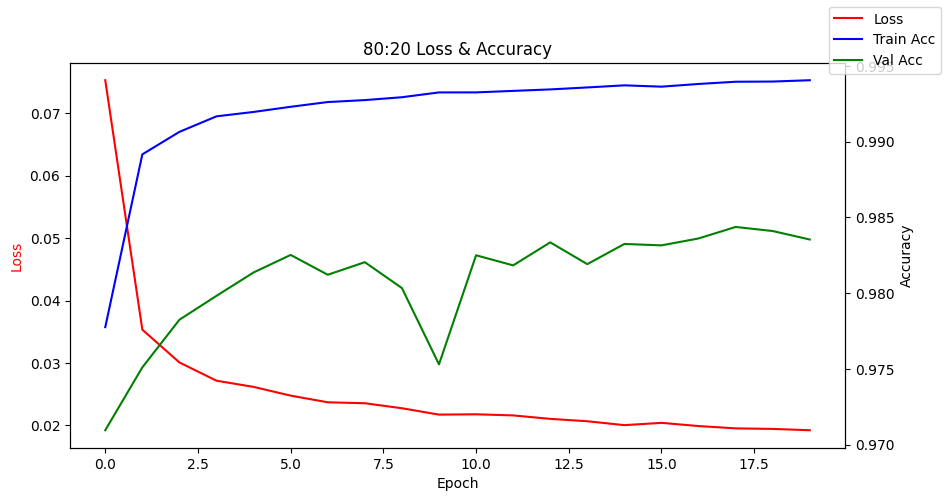

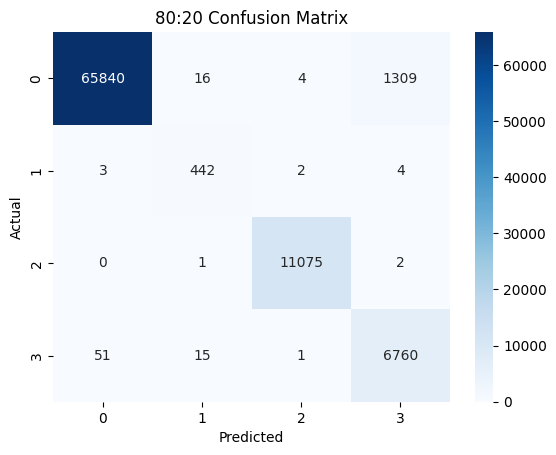

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.93      0.98      0.96       451
           2       1.00      1.00      1.00     11078
           3       0.84      0.99      0.91      6827

    accuracy                           0.98     85525
   macro avg       0.94      0.99      0.96     85525
weighted avg       0.99      0.98      0.98     85525



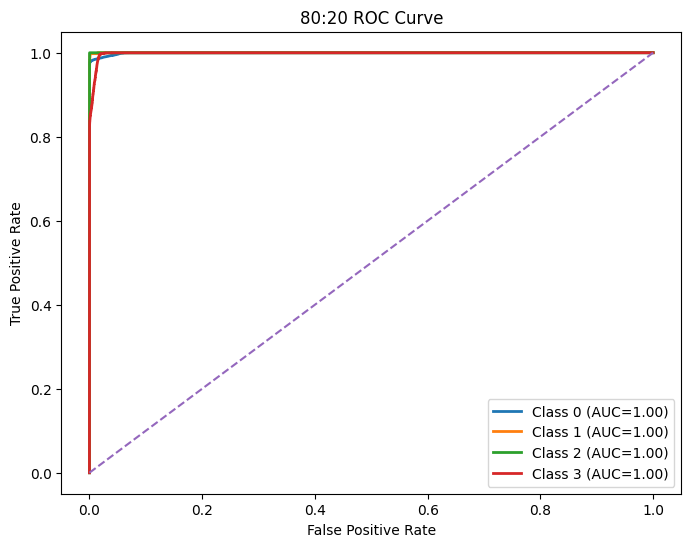

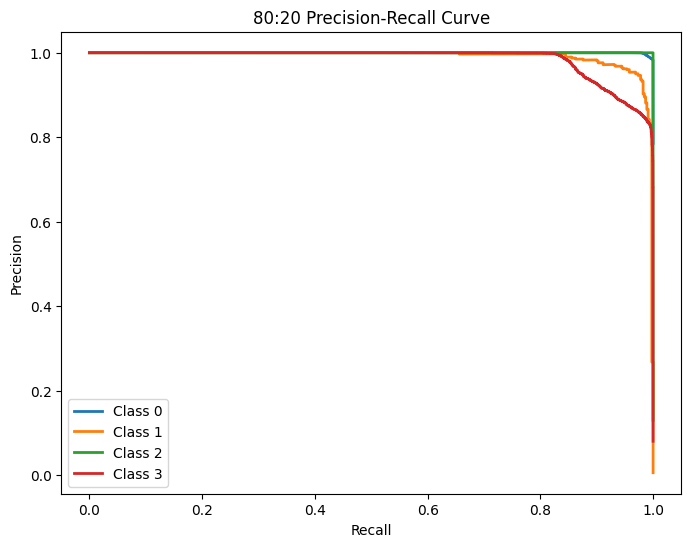


⏱️ Runtime: 1464.79 sec
💾 RAM used: 385.36 MB


In [24]:
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_adasyn(df, "60:40", test_size=0.4)
run_split_adasyn(df, "70:30", test_size=0.3)
run_split_adasyn(df, "80:20", test_size=0.2)

# ADASYN + Tomek_Links

In [10]:
from sklearn.preprocessing import RobustScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks   # ✅ NEW


def run_split_adasyn_tomek(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    # =============================
    # DATA PREP
    # =============================
    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # =============================
    # BEFORE SAMPLING
    # =============================
    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train BEFORE Sampling"
    )
    plt.show()

    # =============================
    # ADASYN (Oversampling)
    # =============================
    adasyn = ADASYN(random_state=42)
    X_train, y_train = adasyn.fit_resample(X_train, y_train)

    # =============================
    # TOMEK LINKS (Cleaning)
    # =============================
    tomek = TomekLinks()
    X_train, y_train = tomek.fit_resample(X_train, y_train)

    # After Sampling
    pd.Series(y_train).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Train AFTER ADASYN + Tomek"
    )
    plt.show()

    # =============================
    # SCALING
    # =============================
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    pd.Series(y_test).value_counts().sort_index().plot(
        kind="bar", title=f"{ratio_name} Test Distribution"
    )
    plt.show()

    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    # =============================
    # LOADERS
    # =============================
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # =============================
    # MODEL
    # =============================
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # =============================
    # TRAINING
    # =============================
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # =============================
    # LOSS + ACCURACY PLOT
    # =============================
    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(history["loss"], color="red", label="Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], color="blue", label="Train Acc")
    ax2.plot(history["val_acc"], color="green", label="Val Acc")
    ax2.set_ylabel("Accuracy")

    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # =============================
    # CONFUSION MATRIX
    # =============================
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # =============================
    # ROC CURVE
    # =============================
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc_val:.2f})")

    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # =============================
    # PRECISION-RECALL CURVE
    # =============================
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # =============================
    # RUNTIME + MEMORY
    # =============================
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\n⏱️ Runtime: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========


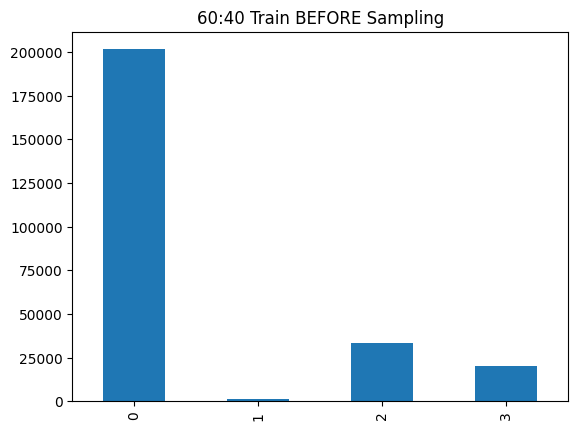

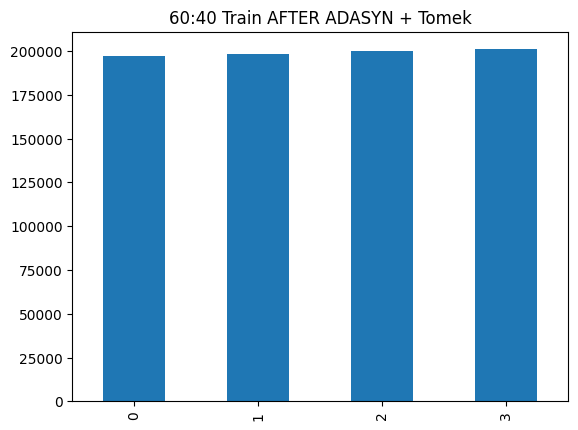

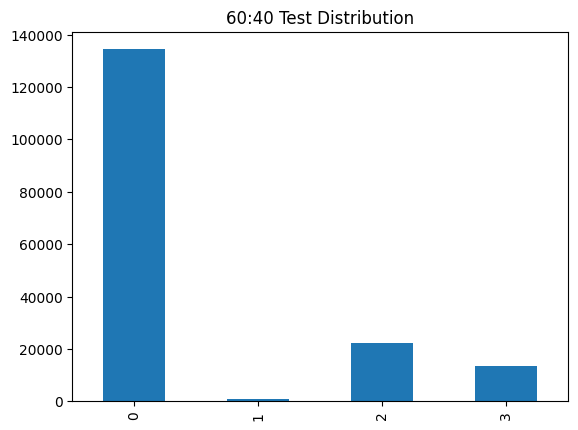

Train size: 796541
Test size : 171050
Epoch 1: Loss=0.0843, TrainAcc=0.9756, TestAcc=0.9748, ROC-AUC=0.9988
Epoch 2: Loss=0.0339, TrainAcc=0.9897, TestAcc=0.9774, ROC-AUC=0.9991
Epoch 3: Loss=0.0283, TrainAcc=0.9913, TestAcc=0.9800, ROC-AUC=0.9992
Epoch 4: Loss=0.0258, TrainAcc=0.9920, TestAcc=0.9779, ROC-AUC=0.9992
Epoch 5: Loss=0.0246, TrainAcc=0.9925, TestAcc=0.9801, ROC-AUC=0.9993
Epoch 6: Loss=0.0227, TrainAcc=0.9930, TestAcc=0.9783, ROC-AUC=0.9993
Epoch 7: Loss=0.0231, TrainAcc=0.9928, TestAcc=0.9811, ROC-AUC=0.9992
Epoch 8: Loss=0.0215, TrainAcc=0.9934, TestAcc=0.9828, ROC-AUC=0.9994
Epoch 9: Loss=0.0210, TrainAcc=0.9937, TestAcc=0.9824, ROC-AUC=0.9994
Epoch 10: Loss=0.0208, TrainAcc=0.9936, TestAcc=0.9811, ROC-AUC=0.9993
Epoch 11: Loss=0.0205, TrainAcc=0.9938, TestAcc=0.9780, ROC-AUC=0.9993
Epoch 12: Loss=0.0195, TrainAcc=0.9939, TestAcc=0.9820, ROC-AUC=0.9992
Epoch 13: Loss=0.0197, TrainAcc=0.9940, TestAcc=0.9821, ROC-AUC=0.9994
Epoch 14: Loss=0.0191, TrainAcc=0.9941, TestAcc=

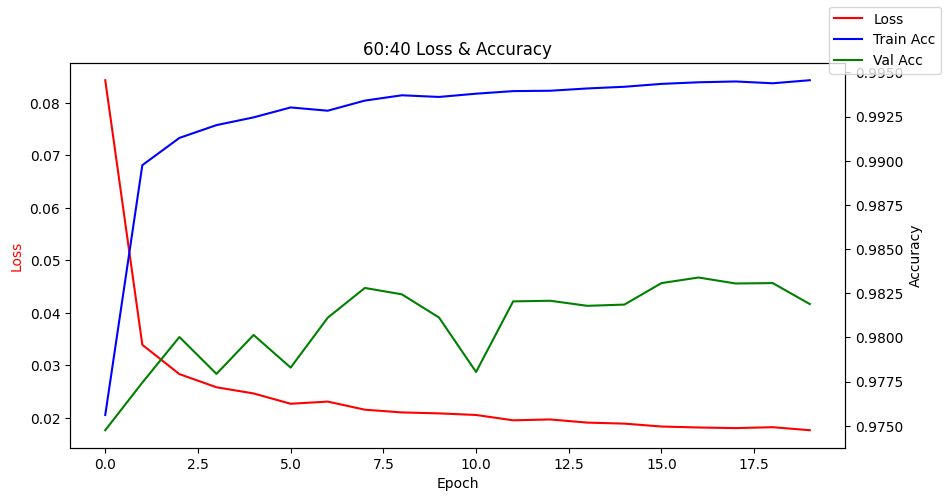

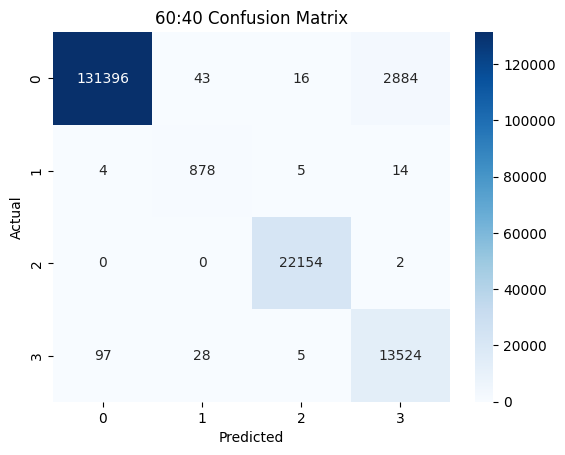

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.93      0.97      0.95       901
           2       1.00      1.00      1.00     22156
           3       0.82      0.99      0.90     13654

    accuracy                           0.98    171050
   macro avg       0.94      0.99      0.96    171050
weighted avg       0.98      0.98      0.98    171050



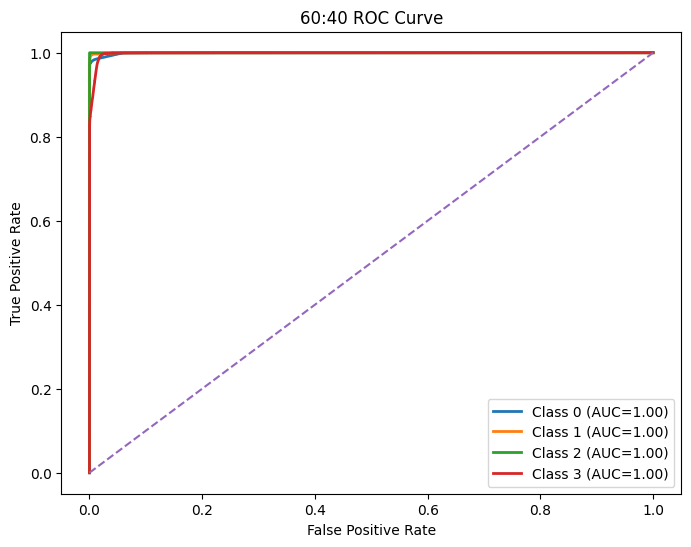

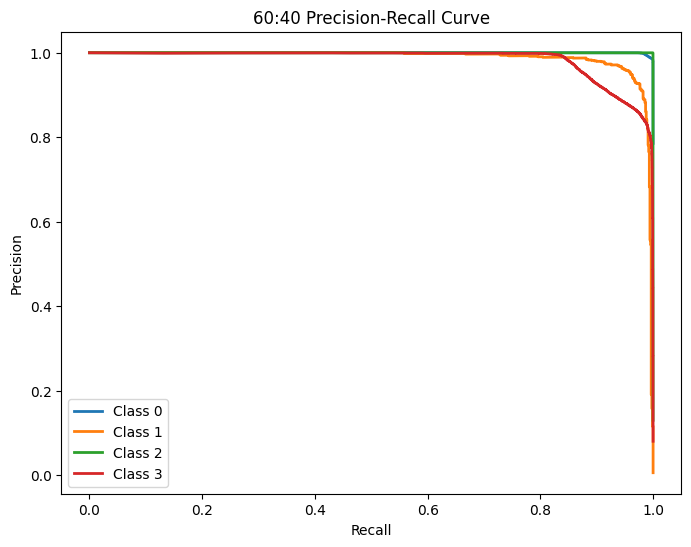


⏱️ Runtime: 2842.02 sec
💾 RAM used: 1067.40 MB

========== 70:30 ==========


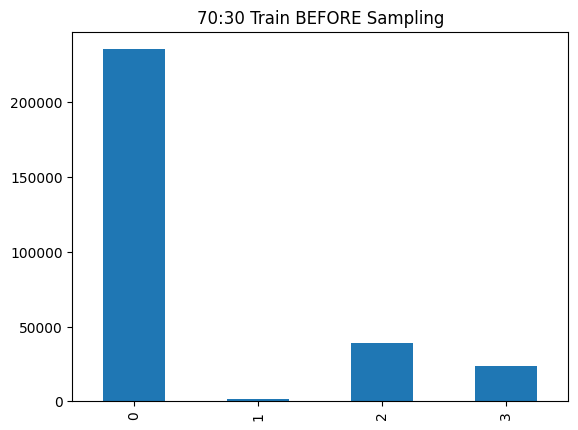

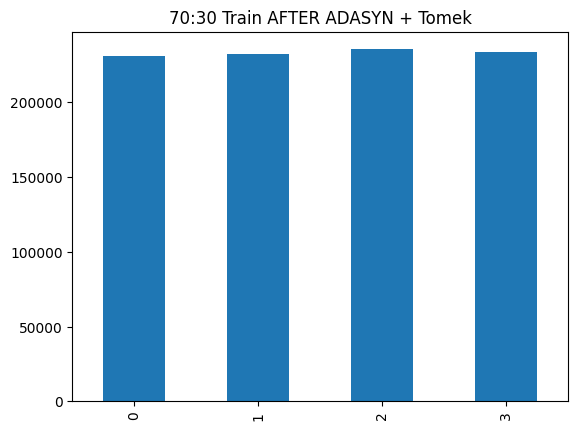

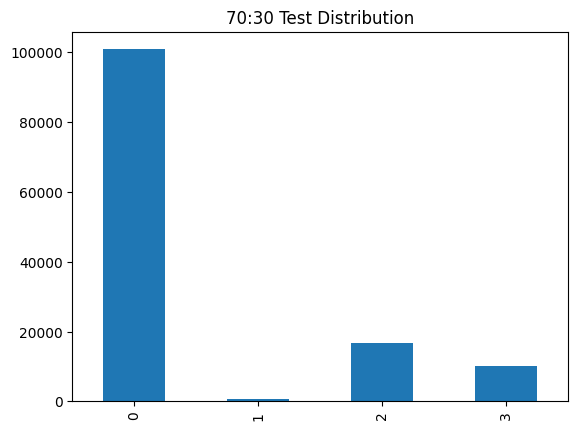

Train size: 931135
Test size : 128288
Epoch 1: Loss=0.0745, TrainAcc=0.9766, TestAcc=0.9755, ROC-AUC=0.9984
Epoch 2: Loss=0.0345, TrainAcc=0.9897, TestAcc=0.9768, ROC-AUC=0.9991
Epoch 3: Loss=0.0291, TrainAcc=0.9911, TestAcc=0.9796, ROC-AUC=0.9992
Epoch 4: Loss=0.0266, TrainAcc=0.9919, TestAcc=0.9803, ROC-AUC=0.9991
Epoch 5: Loss=0.0253, TrainAcc=0.9924, TestAcc=0.9779, ROC-AUC=0.9991
Epoch 6: Loss=0.0238, TrainAcc=0.9928, TestAcc=0.9807, ROC-AUC=0.9992
Epoch 7: Loss=0.0229, TrainAcc=0.9932, TestAcc=0.9815, ROC-AUC=0.9993
Epoch 8: Loss=0.0221, TrainAcc=0.9934, TestAcc=0.9821, ROC-AUC=0.9991
Epoch 9: Loss=0.0221, TrainAcc=0.9933, TestAcc=0.9818, ROC-AUC=0.9992
Epoch 10: Loss=0.0209, TrainAcc=0.9936, TestAcc=0.9831, ROC-AUC=0.9993
Epoch 11: Loss=0.0209, TrainAcc=0.9936, TestAcc=0.9825, ROC-AUC=0.9993
Epoch 12: Loss=0.0202, TrainAcc=0.9939, TestAcc=0.9815, ROC-AUC=0.9994
Epoch 13: Loss=0.0196, TrainAcc=0.9941, TestAcc=0.9831, ROC-AUC=0.9993
Epoch 14: Loss=0.0197, TrainAcc=0.9940, TestAcc=

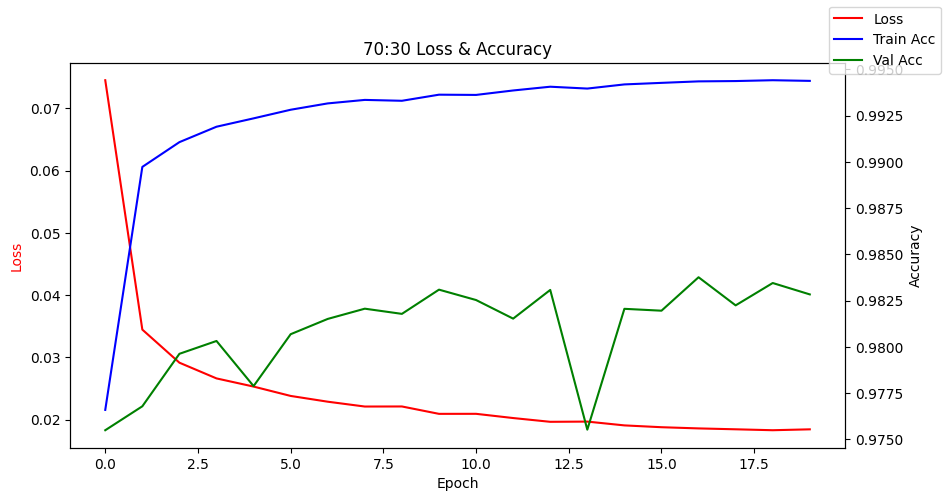

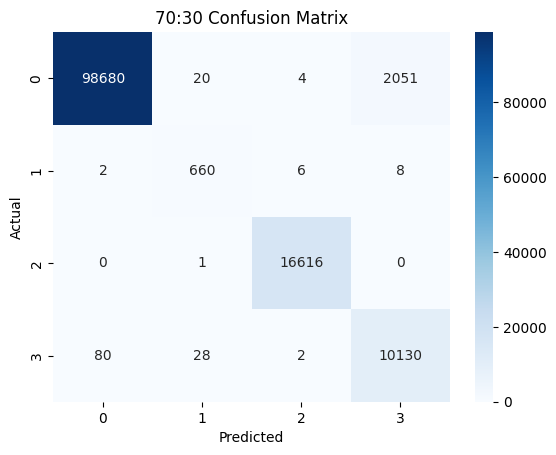

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.93      0.98      0.95       676
           2       1.00      1.00      1.00     16617
           3       0.83      0.99      0.90     10240

    accuracy                           0.98    128288
   macro avg       0.94      0.99      0.96    128288
weighted avg       0.99      0.98      0.98    128288



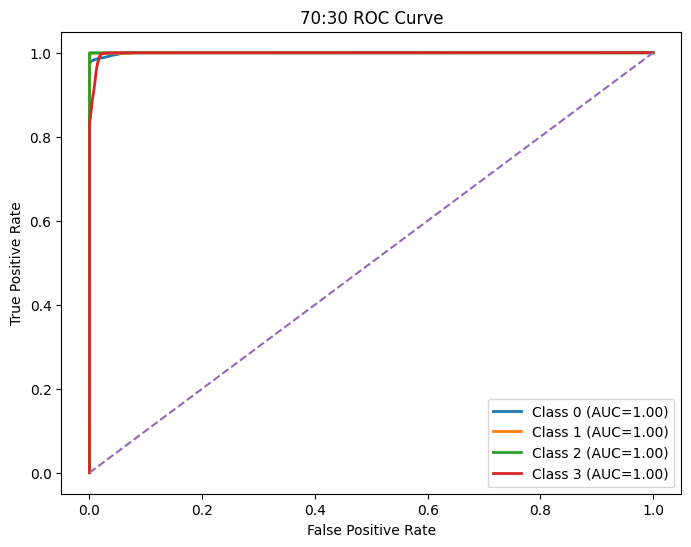

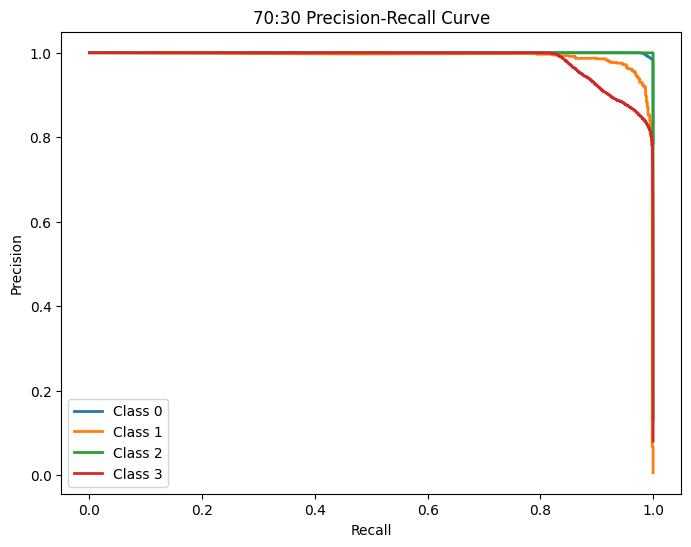


⏱️ Runtime: 3798.19 sec
💾 RAM used: 379.43 MB

========== 80:20 ==========


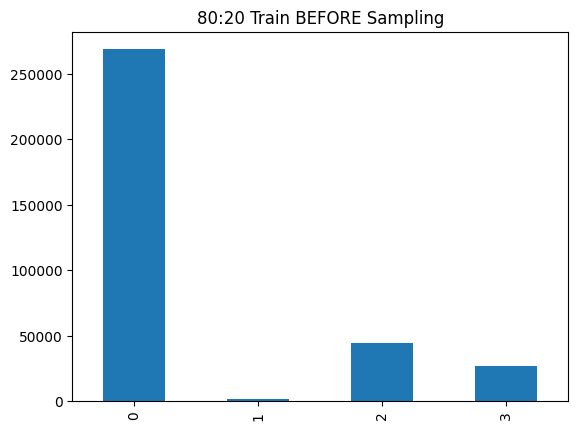

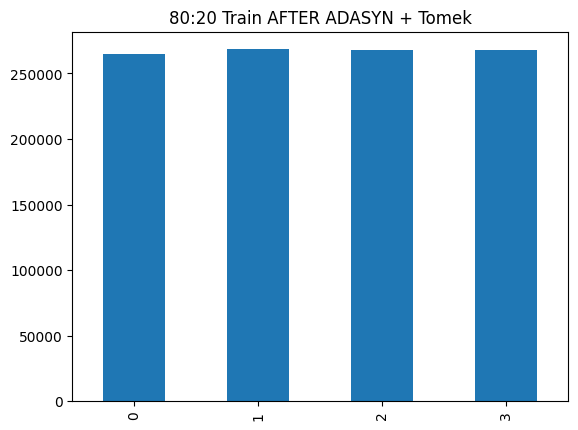

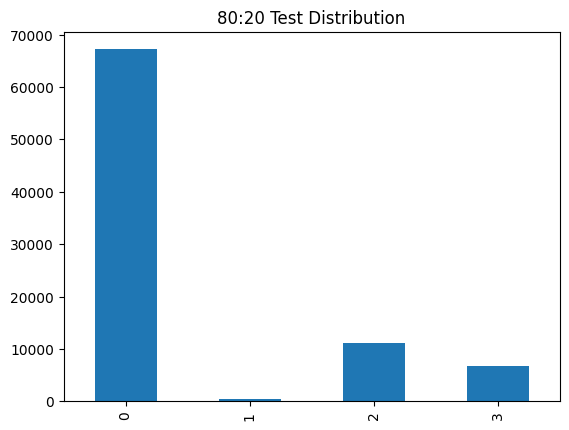

Train size: 1068144
Test size : 85525
Epoch 1: Loss=0.0709, TrainAcc=0.9780, TestAcc=0.9772, ROC-AUC=0.9989
Epoch 2: Loss=0.0335, TrainAcc=0.9900, TestAcc=0.9764, ROC-AUC=0.9991
Epoch 3: Loss=0.0288, TrainAcc=0.9915, TestAcc=0.9808, ROC-AUC=0.9993
Epoch 4: Loss=0.0263, TrainAcc=0.9922, TestAcc=0.9816, ROC-AUC=0.9990
Epoch 5: Loss=0.0253, TrainAcc=0.9925, TestAcc=0.9801, ROC-AUC=0.9992
Epoch 6: Loss=0.0238, TrainAcc=0.9929, TestAcc=0.9829, ROC-AUC=0.9993
Epoch 7: Loss=0.0230, TrainAcc=0.9931, TestAcc=0.9819, ROC-AUC=0.9993
Epoch 8: Loss=0.0224, TrainAcc=0.9931, TestAcc=0.9833, ROC-AUC=0.9994
Epoch 9: Loss=0.0218, TrainAcc=0.9934, TestAcc=0.9809, ROC-AUC=0.9993
Epoch 10: Loss=0.0210, TrainAcc=0.9936, TestAcc=0.9825, ROC-AUC=0.9993
Epoch 11: Loss=0.0204, TrainAcc=0.9938, TestAcc=0.9831, ROC-AUC=0.9994
Epoch 12: Loss=0.0202, TrainAcc=0.9939, TestAcc=0.9831, ROC-AUC=0.9994
Epoch 13: Loss=0.0198, TrainAcc=0.9940, TestAcc=0.9819, ROC-AUC=0.9994
Epoch 14: Loss=0.0195, TrainAcc=0.9941, TestAcc=

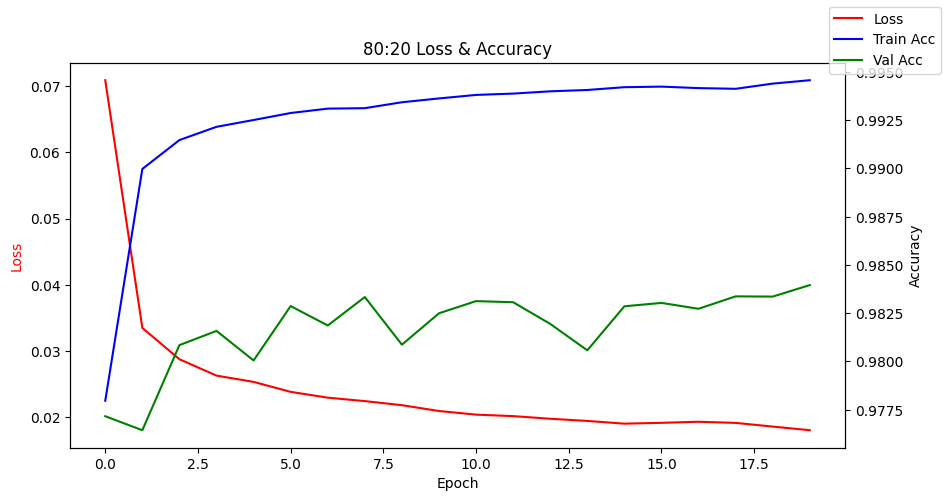

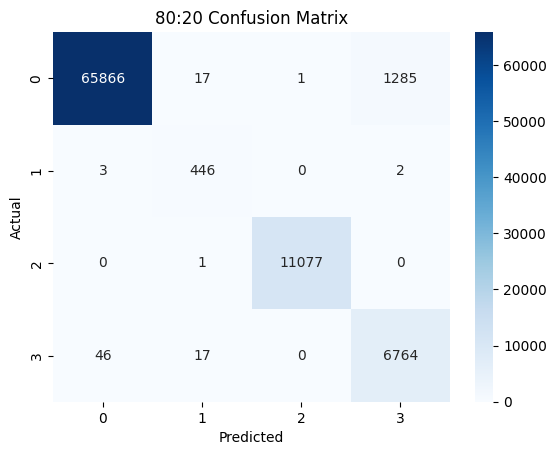

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.93      0.99      0.96       451
           2       1.00      1.00      1.00     11078
           3       0.84      0.99      0.91      6827

    accuracy                           0.98     85525
   macro avg       0.94      0.99      0.96     85525
weighted avg       0.99      0.98      0.98     85525



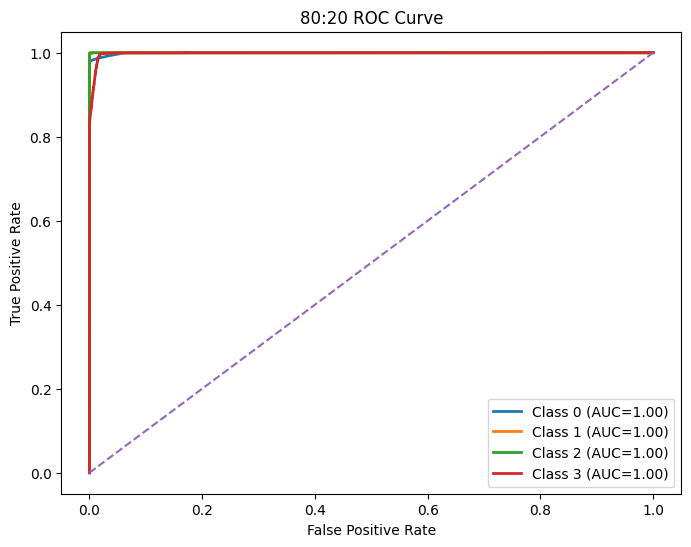

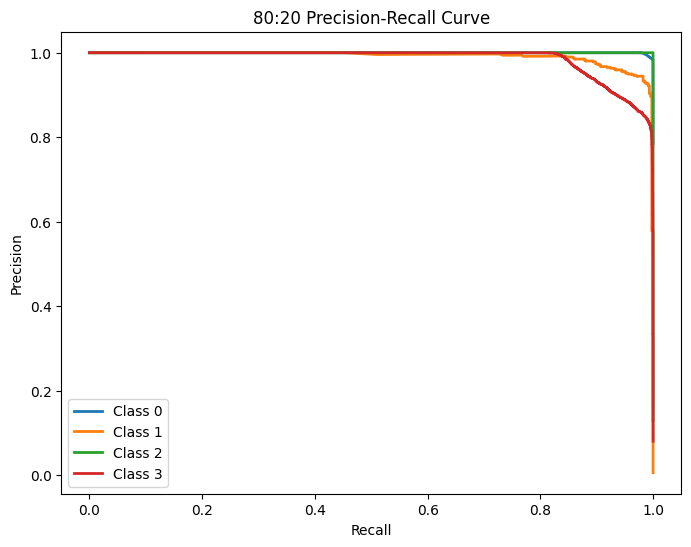


⏱️ Runtime: 4983.53 sec
💾 RAM used: 392.04 MB


In [11]:

df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_adasyn_tomek(df, "60:40", test_size=0.4)
run_split_adasyn_tomek(df, "70:30", test_size=0.3)
run_split_adasyn_tomek(df, "80:20", test_size=0.2)

In [12]:
!pip install numpy